# COMP0189 CW1

## Setup and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import wilcoxon
from scipy.special import expit

from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import (
    StratifiedGroupKFold, GridSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, precision_score, f1_score,
    balanced_accuracy_score, brier_score_loss,
    roc_curve, precision_recall_curve
)

DATA_DIR = '/content/drive/MyDrive/00_Masters_Studies_&_Planning/Courses/Term2/COMP0189 (Test)/CW1/dataset_diabetes/'
FIGDIR   = '/content/drive/MyDrive/00_Masters_Studies_&_Planning/Courses/Term2/COMP0189 (Test)/CW1/figures_final/'
SAVE_DIR = '/content/drive/MyDrive/00_Masters_Studies_&_Planning/Courses/Term2/COMP0189 (Test)/CW1/dataset_diabetes/'

import os
os.makedirs(FIGDIR, exist_ok=True)

# defining global plot style for clarity
COLORS      = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
FIGSIZE_SM  = (8, 4)
FIGSIZE_MED = (12, 5)
FIGSIZE_LG  = (14, 6)

## Task 1 — Dataset Description

###1.1 Characteristics

#### Initial Exploratory Data Analysis

In [3]:
df_raw  = pd.read_csv(DATA_DIR + 'diabetic_data.csv')
ids_map = pd.read_csv(DATA_DIR + 'IDs_mapping.csv')

print('Initial Dataset Information')
print(f'Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}')

# original ratio
print(f'Sample-to-feature ratio (all columns): {df_raw.shape[0] / df_raw.shape[1]:.0f}:1')

# ratio excluding IDs and target
excluded_cols = ['encounter_id', 'patient_nbr', 'readmitted']
n_features_excl = df_raw.drop(columns=excluded_cols).shape[1]
print(f'Sample-to-feature ratio (excluding IDs + target): {df_raw.shape[0] / n_features_excl:.0f}:1')

print('\nColumn dtype counts')
print(df_raw.dtypes.value_counts())

print('\nNumeric feature summary:')
num_cols = df_raw.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['encounter_id','patient_nbr']]
display(df_raw[num_cols].describe().round(2))

Initial Dataset Information
Rows: 101,766   Columns: 50
Sample-to-feature ratio (all columns): 2035:1
Sample-to-feature ratio (excluding IDs + target): 2165:1

Column dtype counts
object    37
int64     13
Name: count, dtype: int64

Numeric feature summary:


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


In [ ]:
#checking missing values in cardinal numeric features
import pandas as pd
df = pd.read_csv(DATA_DIR + 'diabetic_data.csv')
numeric_feats = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                 'num_medications', 'number_outpatient', 'number_emergency',
                 'number_inpatient', 'number_diagnoses']
print(df[numeric_feats].isnull().sum())
print((df[numeric_feats] == '?').sum())

time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
dtype: int64
time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
dtype: int64


In [5]:
#getting an idea of categories for each feature
print('Complete Feature List and Metadata')
df_raw.info(verbose=True, show_counts=True)

all_features = df_raw.columns.tolist()
print('\nFeature Names:')
for i, feature in enumerate(all_features, 1):
    print(f'{i}. {feature}')

cat_cols = df_raw.select_dtypes(include='object').columns

print('\nCategorical Feature Categories (Frequency Ordered)')

for col in cat_cols:
    # Get all unique values sorted by frequency
    value_counts = df_raw[col].value_counts()
    unique_count = len(value_counts)

    # only showing categories up to 10 for clarity
    if unique_count <= 10:
        display_list = value_counts.index.tolist()
        label = f'All {unique_count} Categories'
    else:
        display_list = value_counts.head(10).index.tolist()
        label = f'Top 10 of {unique_count} Categories'

    print(f'Feature: {col}')
    print(f'Status:  {label}')
    print(f'Values:  {display_list}')

print("\nInspecting encounter_id:")

# checking if encounter_id is unique for every row
is_unique = df_raw['encounter_id'].is_unique
unique_count = df_raw['encounter_id'].nunique()

print(f'Total Unique IDs: {unique_count:,}')
print(f'Sample Values: {df_raw["encounter_id"].head(5).tolist()}')

Complete Feature List and Metadata
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures          

In [6]:
# Listing the 23 medication dosage features
med_features = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

print('Medication Category Distribution and Dominance')

for med in med_features:
    if med in df_raw.columns:
        # getting counts including NaNs
        counts = df_raw[med].value_counts(dropna=False)
        total = counts.sum()

        # finding most common category - want to see how many have close to zero variance
        most_common_cat = counts.index[0]
        most_common_count = counts.iloc[0]
        most_common_pct = (most_common_count / total) * 100

        print(f'\nMEDICATION: {med.upper()}')
        print(f'Most Common Category: {most_common_cat} (${most_common_pct:.2f}\%$)')
        print('-' * 40)

        for category, count in counts.items():
            pct = (count / total) * 100
            print(f'{str(category):<15} : {count:>7} patients (${pct:.2f}\%$)')


Medication Category Distribution and Dominance

MEDICATION: METFORMIN
Most Common Category: No ($80.36\%$)
----------------------------------------
No              :   81778 patients ($80.36\%$)
Steady          :   18346 patients ($18.03\%$)
Up              :    1067 patients ($1.05\%$)
Down            :     575 patients ($0.57\%$)

MEDICATION: REPAGLINIDE
Most Common Category: No ($98.49\%$)
----------------------------------------
No              :  100227 patients ($98.49\%$)
Steady          :    1384 patients ($1.36\%$)
Up              :     110 patients ($0.11\%$)
Down            :      45 patients ($0.04\%$)

MEDICATION: NATEGLINIDE
Most Common Category: No ($99.31\%$)
----------------------------------------
No              :  101063 patients ($99.31\%$)
Steady          :     668 patients ($0.66\%$)
Up              :      24 patients ($0.02\%$)
Down            :      11 patients ($0.01\%$)

MEDICATION: CHLORPROPAMIDE
Most Common Category: No ($99.92\%$)
-------------------------

Developing Table 1: Raw Summary Statistics

In [7]:
df_raw = pd.read_csv(DATA_DIR + 'diabetic_data.csv')

id_cols = ['encounter_id', 'patient_nbr']
num_cols = [c for c in df_raw.select_dtypes(include='number').columns
            if c not in id_cols]
med_indicators = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
diag_cols  = ['diag_1', 'diag_2', 'diag_3']
other_cat  = ['race', 'gender', 'age', 'weight', 'payer_code',
              'medical_specialty', 'max_glu_serum', 'A1Cresult',
              'change', 'diabetesMed']
target_col = ['readmitted']

HIGH_CARD_THRESHOLD = 10  # list categories only if <= this

def format_categories(s, n_unique):
    if n_unique <= HIGH_CARD_THRESHOLD:
        return ', '.join([str(c) for c in s.value_counts().index.tolist()])
    else:
        return f'{n_unique} unique values'

print('='*120)
print('TABLE 1: RAW SUMMARY STATISTICS')
print('='*120)
print(f'{"Feature":<38} {"dtype":<10} {"Median":<12} {"Cardinality":<14} {"Categories / Notes"}')
print('-'*120)

#  numeric
print('\n--- NUMERIC (11 features) ---')
for col in num_cols:
    s      = df_raw[col]
    median = f'{s.median():.1f}'
    iqr    = f'(IQR={s.quantile(0.75)-s.quantile(0.25):.1f})'
    dtype  = str(s.dtype)
    notes  = f'range=[{s.min():.0f},{s.max():.0f}]  skew={s.skew():.2f}'
    print(f'{col:<38} {dtype:<10} {median+" "+iqr:<12} {"---":<14} {notes}')

# individual categorical
print('\n--- CATEGORICAL — INDIVIDUAL ---')
for col in other_cat + diag_cols + target_col:
    s        = df_raw[col]
    dtype    = str(s.dtype)
    n_unique = s.nunique()
    cat_str  = format_categories(s, n_unique)
    print(f'{col:<38} {dtype:<10} {"---":<12} {n_unique:<14} {cat_str}')

# grouping medication indicators for clarity
print('\n--- MEDICATION INDICATORS (23 features, grouped) ---')
all_med_cats = sorted(set(
    v for col in med_indicators for v in df_raw[col].unique()
))
card_min = min(df_raw[c].nunique() for c in med_indicators)
card_max = max(df_raw[c].nunique() for c in med_indicators)
print(f'{"23 dosage indicators":<38} {"object":<10} {"---":<12} '
      f'{str(card_min)+"--"+str(card_max):<14} '
      f'{", ".join(all_med_cats)} (subset per drug)')

TABLE 1: RAW SUMMARY STATISTICS
Feature                                dtype      Median       Cardinality    Categories / Notes
------------------------------------------------------------------------------------------------------------------------

--- NUMERIC (11 features) ---
admission_type_id                      int64      1.0 (IQR=2.0) ---            range=[1,8]  skew=1.59
discharge_disposition_id               int64      1.0 (IQR=3.0) ---            range=[1,28]  skew=2.56
admission_source_id                    int64      7.0 (IQR=6.0) ---            range=[1,25]  skew=1.03
time_in_hospital                       int64      4.0 (IQR=4.0) ---            range=[1,14]  skew=1.13
num_lab_procedures                     int64      44.0 (IQR=26.0) ---            range=[1,132]  skew=-0.24
num_procedures                         int64      1.0 (IQR=2.0) ---            range=[0,6]  skew=1.32
num_medications                        int64      15.0 (IQR=10.0) ---            range=[1,81]  skew

Fig 1: Cadinal numeric feature distributions (excludes integer-encoded categorical variables)

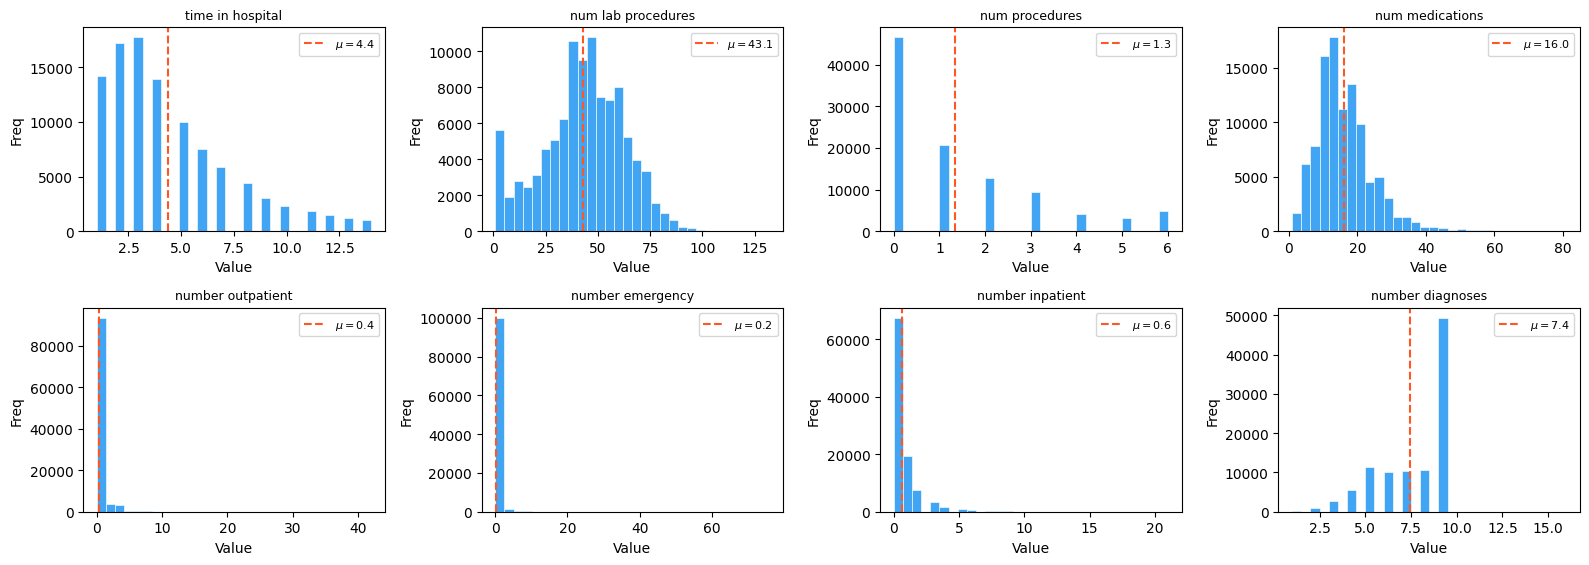

In [8]:
import matplotlib.pyplot as plt
import math

# selecting all numeric features
continuous_raw = df_raw.select_dtypes(include=['number']).columns.tolist()
# exclude IDs if present in your dataset & only include cardinal numeric features
ids_to_exclude = ['encounter_id', 'patient_nbr',
                  'admission_type_id', 'discharge_disposition_id',
                  'admission_source_id']
continuous_raw = [col for col in continuous_raw if col not in ids_to_exclude]

# Calculate grid dimensions
n_features = len(continuous_raw)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_raw):
    # Plot histogram
    data = df_raw[col].dropna()
    axes[i].hist(data, bins=30, color=COLORS[0], edgecolor='white',
                 alpha=0.85, linewidth=0.5)

    axes[i].set_title(col.replace('_', ' '), fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Freq')

    # printing mean
    m = data.mean()
    axes[i].axvline(m, color=COLORS[1], linestyle='--', linewidth=1.5,
                    label=f'$\\mu={m:.1f}$')
    axes[i].legend(fontsize=8)

# formatting
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGDIR + 'Fig01_numeric_distributions.png', dpi=150, bbox_inches='tight')

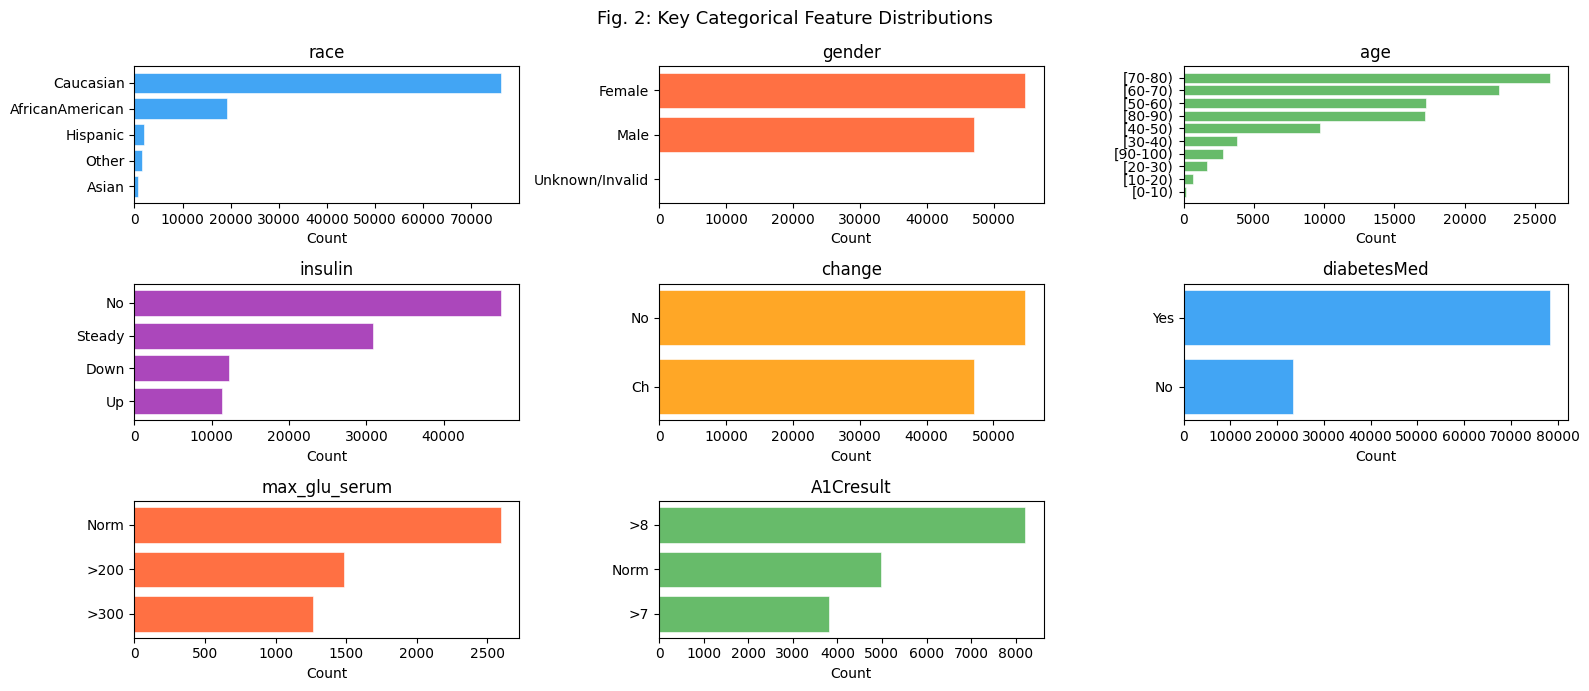

In [9]:
# Exploring main categorical distributions (excluding medications)
cat_features = ['race', 'gender', 'age', 'insulin', 'change', 'diabetesMed', 'max_glu_serum', 'A1Cresult']

fig, axes = plt.subplots(3, 3, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    vc = df_raw[col].replace('?', np.nan).dropna().value_counts()
    vc = vc.head(10)
    axes[i].barh(vc.index[::-1], vc.values[::-1], color=COLORS[i % len(COLORS)],
                 edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Count')

axes[-1].axis('off')

plt.suptitle('Fig. 2: Key Categorical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig03_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Fig 2: Categorical class imbalance (excluding high cardinality)

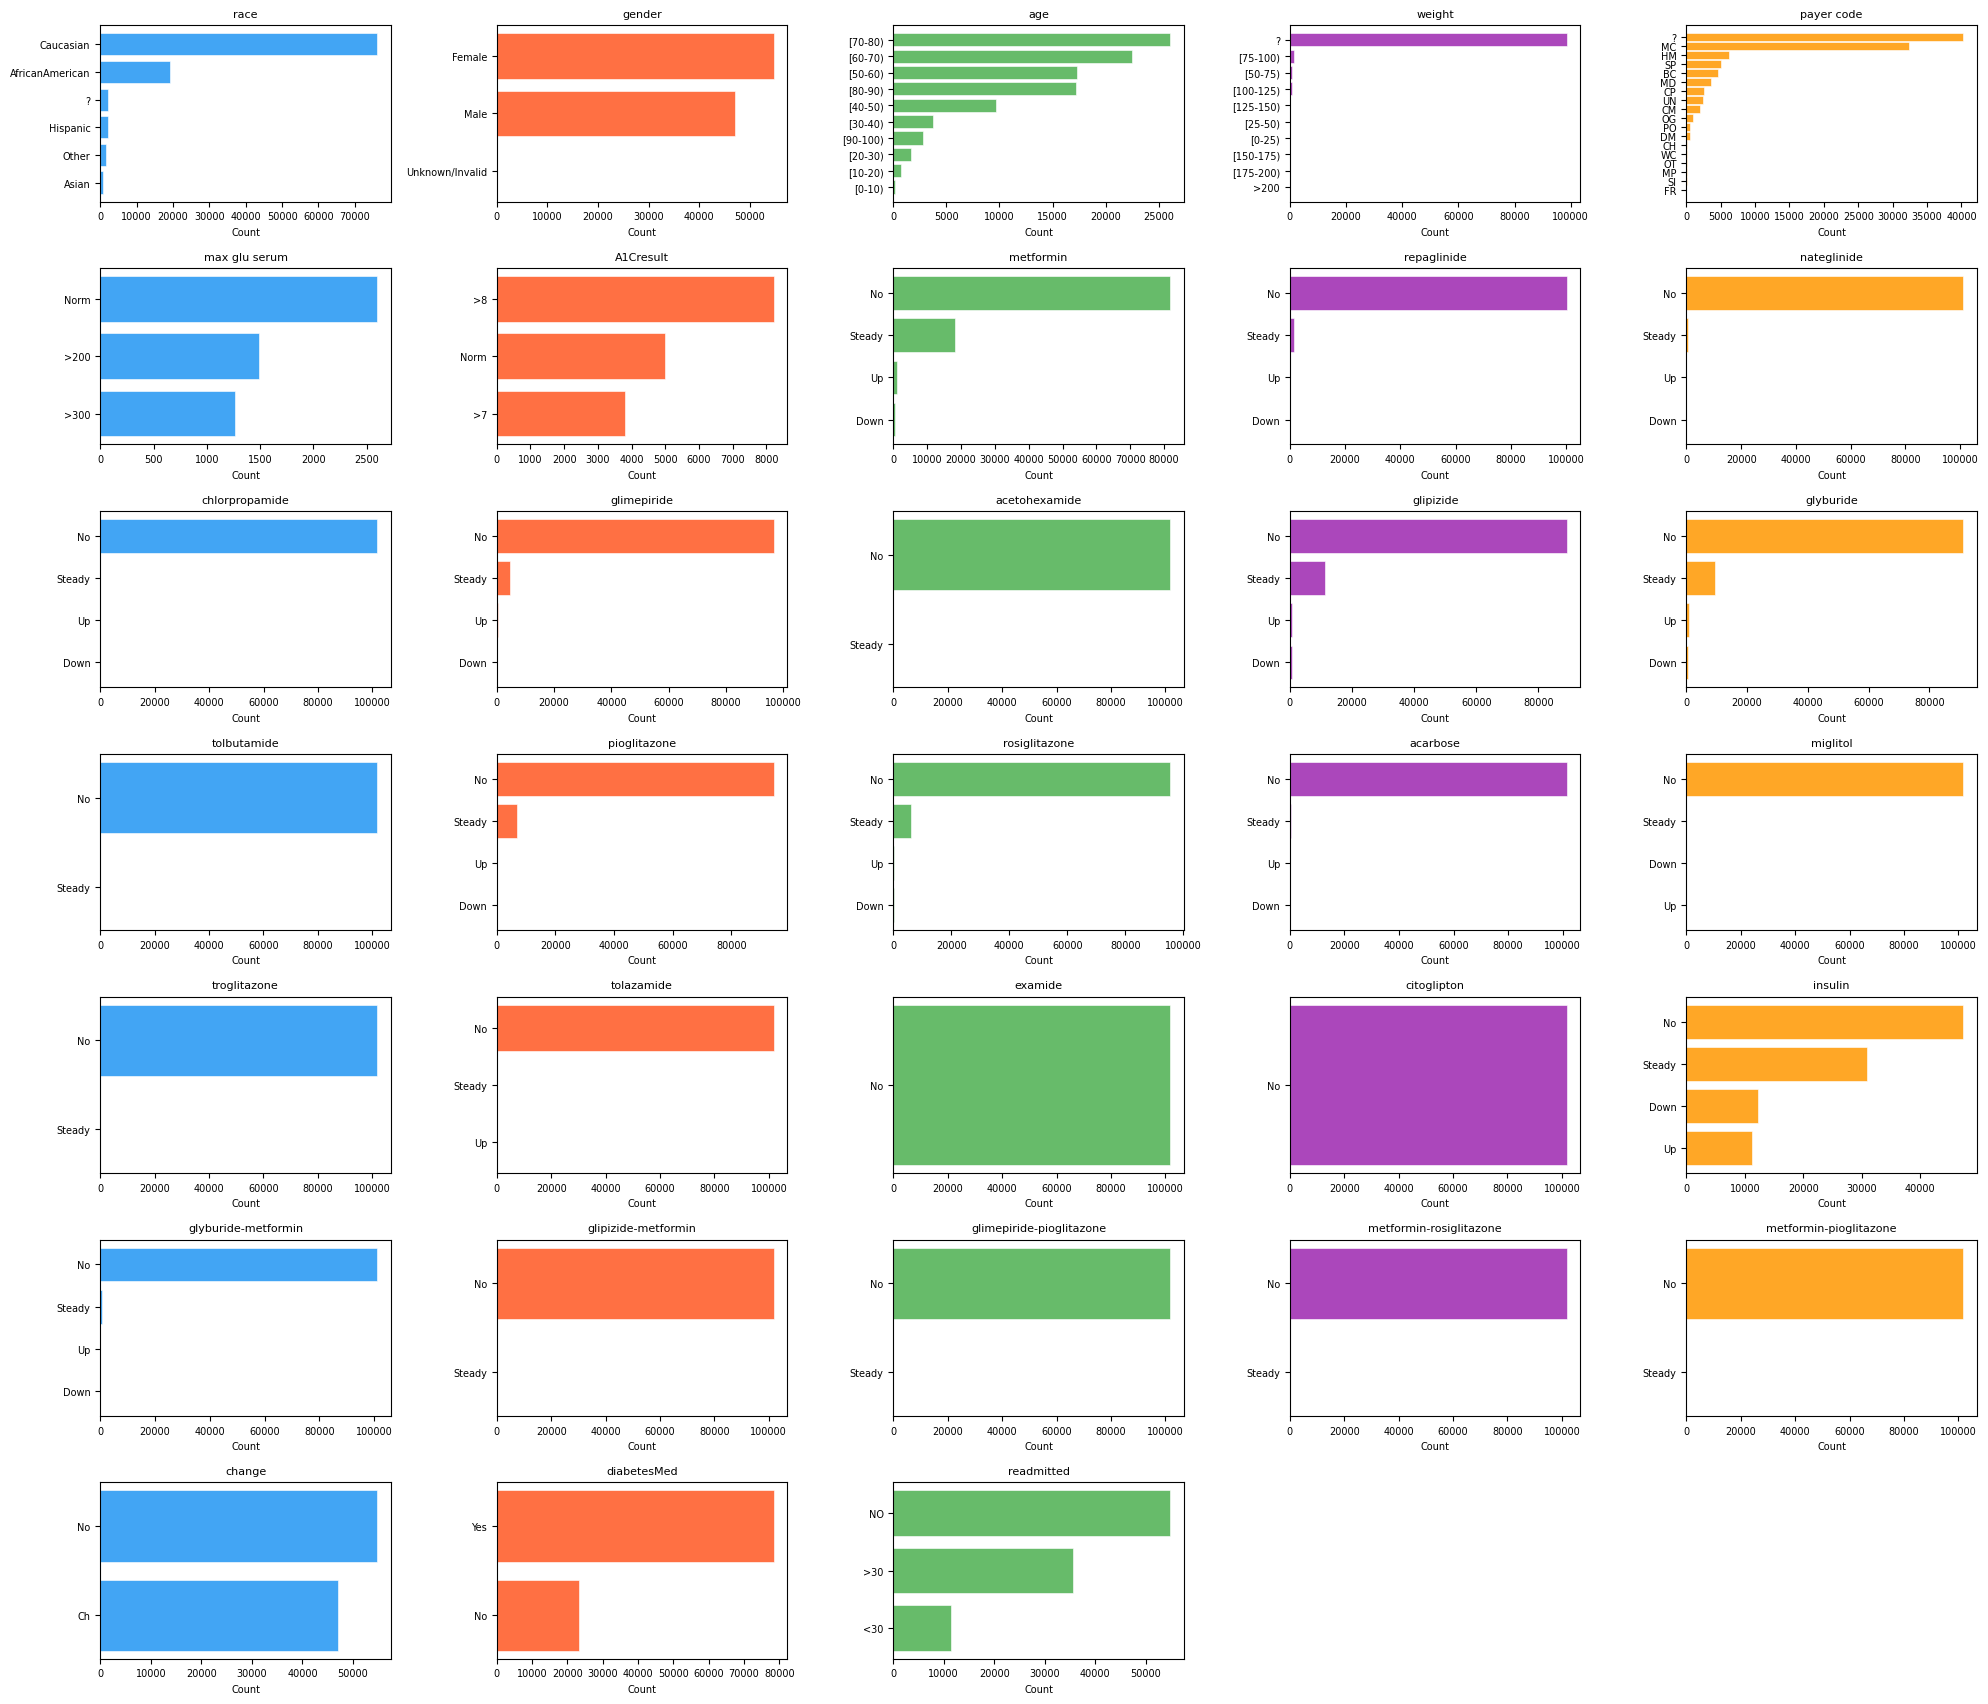

In [10]:
import matplotlib.pyplot as plt
import math

# identifying all categorical features
categorical_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()

# exclude high-cardinality features for clarity (avoiding messy y-axes); keeping medications for more comprehensive view than above
exclude_cols = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3']
categorical_cols = [c for c in categorical_cols if c not in exclude_cols]

# define grid layout for 5 plots per row
n_cols = 5
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # get all value counts without cleaning or limiting
    vc = df_raw[col].value_counts()

    # Plot - horizontal bar chart for clarity
    axes[i].barh(vc.index[::-1], vc.values[::-1],
                 color=COLORS[i % len(COLORS)],
                 edgecolor='white',
                 linewidth=0.5,
                 alpha=0.85)

    axes[i].set_title(col.replace('_', ' '), fontsize=8)
    axes[i].set_xlabel('Count', fontsize=7)
    axes[i].tick_params(axis='both', labelsize=7)

#cleaning up
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIGDIR + 'Fig03_categorical_distributions_full.png', dpi=150, bbox_inches='tight')

Fig 3: Missingness and cardinality

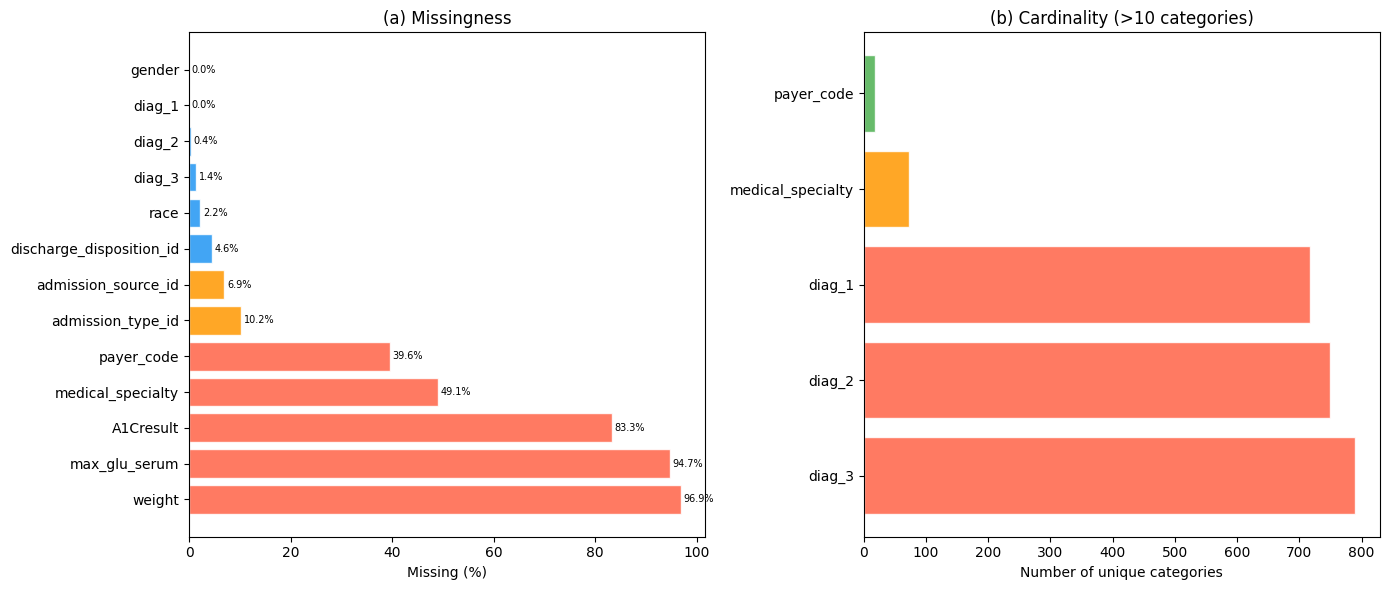

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_miss = df_raw.copy()

# defining the sentinel-encoded missing values
hidden_null_map = {
    'admission_type_id':        [5, 6, 8],
    'discharge_disposition_id': [18, 25, 26],
    'admission_source_id':      [9, 15, 17, 20, 21]
}

# replace IDs and '?' with NaN
for col, ids in hidden_null_map.items():
    if col in df_miss.columns:
        df_miss.loc[df_miss[col].isin(ids), col] = np.nan

df_miss = df_miss.replace('?', np.nan)

# initially replace None with NaN, but these are not truly missing (represent active decision to not administer test)
df_miss['max_glu_serum'] = df_miss['max_glu_serum'].replace('None', np.nan)
df_miss['A1Cresult']     = df_miss['A1Cresult'].replace('None', np.nan)
df_miss['gender'] = df_miss['gender'].replace('Unknown/Invalid', np.nan)

# caculating stats
miss_pct = (df_miss.isnull().mean() * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

# printing features with cardinality over 10
cat_cols_all = [c for c in df_raw.select_dtypes(include='object').columns if c != 'readmitted']
cardinality  = df_raw[cat_cols_all].nunique().sort_values(ascending=False)
high_card    = cardinality[cardinality > 10]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LG)
#highlight misisngness over 30%
colors_miss = ['tomato' if v > 30 else '#FF9800' if v > 5 else COLORS[0]
               for v in miss_pct.values]

axes[0].barh(miss_pct.index, miss_pct.values,
             color=colors_miss, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('(a) Missingness')

for i, v in enumerate(miss_pct.values):
        axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=7)

# plot cardinality for > 10
colors_card = ['tomato' if v > 100 else '#FF9800' if v > 20 else COLORS[2]
                for v in high_card.values]

axes[1].barh(high_card.index, high_card.values,
             color=colors_card, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Number of unique categories')
axes[1].set_title('(b) Cardinality (>10 categories)')

# Cleanup
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig04_missingness_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print(df_raw['diag_1'].value_counts().head(1))

diag_1
428    6862
Name: count, dtype: int64


In [12]:
print(df_raw['gender'].value_counts(dropna=False))
print(f'\nUnknown/Invalid count: {(df_raw["gender"] == "Unknown/Invalid").sum()}')
print(f'As % of total: {(df_raw["gender"] == "Unknown/Invalid").mean()*100:.3f}%')

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Unknown/Invalid count: 3
As % of total: 0.003%


In [13]:
#checking missing in diagnosis categories more thoroughly - beyond 2dp
df_check = df_raw.replace('?', np.nan).copy()

for col in ['diag_1', 'diag_2', 'diag_3']:
    n_miss = df_check[col].isna().sum()
    pct    = n_miss / len(df_check) * 100
    print(f'{col}: {n_miss:,} missing ({pct:.1f}%)')

diag_1: 21 missing (0.0%)
diag_2: 358 missing (0.4%)
diag_3: 1,423 missing (1.4%)


Fig 4: Target class distribution

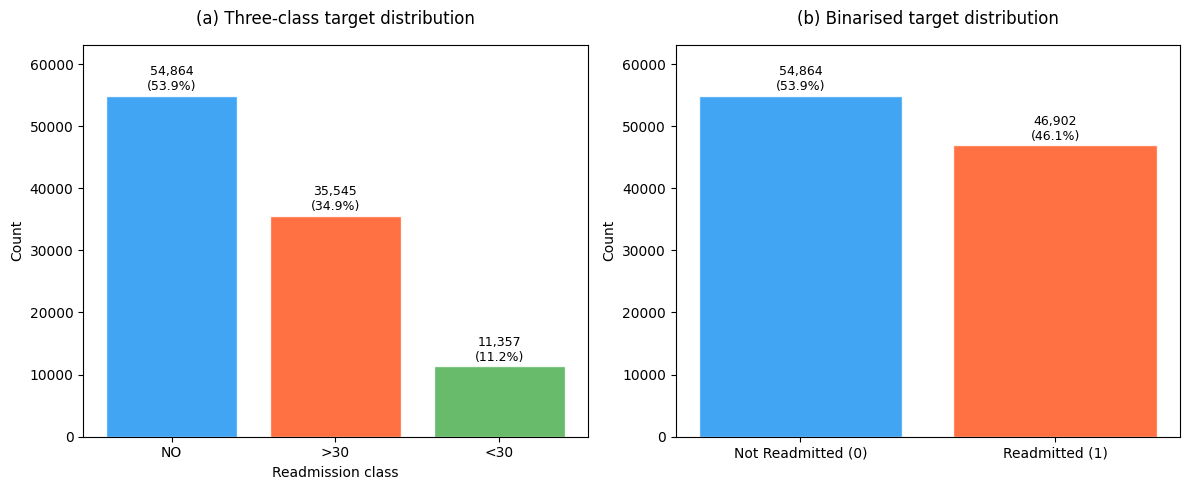

In [14]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_MED)

# plot three class dist to visualise imbalance
vc3 = df_raw['readmitted'].value_counts()
axes[0].bar(vc3.index, vc3.values, color=COLORS[:3], edgecolor='white', alpha=0.85)
for i, (k, v) in enumerate(vc3.items()):
    axes[0].text(i, v + 400, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('(a) Three-class target distribution', pad=15)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Readmission class')
axes[0].set_ylim(0, vc3.max() * 1.15)


# plot binarised target dist
y_bin_all = (df_raw['readmitted'] != 'NO').astype(int)
vc2 = y_bin_all.value_counts().sort_index()
labels = ['Not Readmitted (0)', 'Readmitted (1)']
axes[1].bar(labels, vc2.values, color=COLORS[:2], edgecolor='white', alpha=0.85)
for i, v in enumerate(vc2.values):
    axes[1].text(i, v + 400, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('(b) Binarised target distribution', pad=15)
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, vc2.max() * 1.15)

plt.tight_layout()
plt.savefig(FIGDIR + 'Fig01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

###1.2 Dataset Challenges

Missingness Analysis:

In [16]:
#missingness mechanism analysis to determine appropriate imputation strategy for each feature before pipeline construction
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

#setting up analysis

df_anly = df_raw.copy()

#again define sentinel encoded missing values for integer-encoded categorical IDs - need to be identified explicitly before NaN replacement
hidden_null_map = {
    'admission_type_id':        [5, 6, 8],
    'discharge_disposition_id': [18, 25, 26],
    'admission_source_id':      [9, 15, 17, 20, 21]
}
for col, ids in hidden_null_map.items():
    df_anly.loc[df_anly[col].isin(ids), col] = np.nan
df_anly = df_anly.replace('?', np.nan)

# recoding medically informative "None" values as Not_Tested rather than NaN
MEDICALLY_INFORMATIVE = ['max_glu_serum', 'A1Cresult']
for col in MEDICALLY_INFORMATIVE:
    df_anly[col] = df_anly[col].fillna('Not_Tested')

# we note that diagnosis 2 and 3 are structurally missing - if there is no diagnosis 1, there wont be a diagnosis 2 etc.
STRUCTURAL_MISSING = ['diag_2', 'diag_3']
for col in STRUCTURAL_MISSING:
    df_anly[col] = df_anly[col].fillna('None')

# exclude identifiers
IDENTIFIERS = ['encounter_id', 'patient_nbr']

EXCLUDE_FROM_ANALYSIS = IDENTIFIERS + MEDICALLY_INFORMATIVE + STRUCTURAL_MISSING

# 0.1% missingness threshold - diag_1 has too few missing values for logistic regression to be meaninful
missing_cols = [
    c for c in df_anly.columns
    if df_anly[c].isnull().mean() > 0.001
    and c not in EXCLUDE_FROM_ANALYSIS
]

numeric_predictors = [
    c for c in df_anly.select_dtypes(include=[np.number]).columns
    if c not in IDENTIFIERS + ['readmitted']
]

print(f"Features entering missingness analysis: {missing_cols}")
print(f"Predictors for logistic regression ({len(numeric_predictors)}): {numeric_predictors}\n")


def littles_mcar_test(df):
    """
    this section implements Little's (1988) MCAR test. For each missing data pattern, we compute the
  deviation of observed means from grand means, weighted by pattern size and covariance. We then return
  chi-squared, deg. of freedom, p-value and number of patterns used. Significant p (<0.05) rejects MCAR and
  therefore suggests MAR or MNAR mechanisms (which are not distiguishable exactly) that will require targeted
  treatment.
    """
    df = df.copy() # Ensure this is indented exactly 4 spaces (if using 4-space tabs)
    grand_means = df.mean()
    full_cov = df.cov()
    miss_indicator = df.isnull()
    patterns = miss_indicator.drop_duplicates()

    chi2_stat = 0.0
    total_obs_vars = 0
    n_patterns_used = 0

    for _, pattern in patterns.iterrows():
        match_mask = (miss_indicator == pattern).all(axis=1)
        subdf = df[match_mask]
        n_k = len(subdf)
        if n_k < 2:
            continue
        obs_cols = [c for c in df.columns if not pattern[c]]
        if len(obs_cols) == 0:
            continue
        mu_k = subdf[obs_cols].mean().values
        mu   = grand_means[obs_cols].values
        diff = mu_k - mu
        sub_cov = full_cov.loc[obs_cols, obs_cols]
        if np.linalg.matrix_rank(sub_cov.values) < sub_cov.shape[0]:
            continue
        try:
            cov_inv = np.linalg.inv(sub_cov.values)
            chi2_stat += n_k * (diff @ cov_inv @ diff)
            total_obs_vars += len(obs_cols)
            n_patterns_used += 1
        except np.linalg.LinAlgError:
            continue

    p_with_missing = miss_indicator.any(axis=0).sum()
    dof = max(total_obs_vars - p_with_missing, 1)
    little_p = 1 - chi2.cdf(chi2_stat, dof)
    return chi2_stat, dof, little_p, n_patterns_used

print("=" * 70)
print("STEP 1: Little's MCAR Test")
print("=" * 70)

numeric_for_little = [
    c for c in df_anly.select_dtypes(include=[np.number]).columns
    if c not in IDENTIFIERS + ['readmitted'] and df_anly[c].isnull().any()
]
print(f"  Numeric features with missingness: {numeric_for_little}")

df_little = df_anly[numeric_for_little].copy()

# fixing bug -  store as little_chi2, little_dof, little_p — never overwritten
little_chi2, little_dof, little_p, n_patterns = littles_mcar_test(df_little)
little_rejected = little_p < 0.05

print(f"\n  Patterns found: {n_patterns}")
print(f"  Chi-squared = {little_chi2:.3f}, df = {little_dof}, p = {little_p:.6f}")
if little_rejected:
    print("  → MCAR REJECTED: data is MAR or MNAR.")
else:
    print("  → Cannot reject MCAR.")
print()


print("=" * 70)
print("STEP 2: MAR Test — Logistic Regression of Missingness Indicator")
print("=" * 70)

#Bonferroni correction across all missingness tests run simultaneously — controls family-wise error rate to avoid spurious MAR classifications
alpha_mar = 0.05 / len(missing_cols)
print(f"\n  Bonferroni-corrected α = {alpha_mar:.5f} ({len(missing_cols)} tests)\n")

mar_results = {}

for target_col in missing_cols:
    y = df_anly[target_col].isnull().astype(int)
    if y.nunique() < 2:
        continue

    pred_cols = [c for c in numeric_predictors if c != target_col]
    X_raw = df_anly[pred_cols].apply(lambda col: col.fillna(col.median()))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    lr = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs', random_state=42)
    lr.fit(X_scaled, y)
    y_prob = lr.predict_proba(X_scaled)[:, 1]

    auc = roc_auc_score(y, y_prob)

    eps = 1e-12
    ll_fit  = np.sum(y * np.log(y_prob + eps) + (1-y) * np.log(1-y_prob + eps))
    p_null  = y.mean()
    ll_null = np.sum(y * np.log(p_null+eps) + (1-y) * np.log(1-p_null+eps))
    lr_stat = 2 * (ll_fit - ll_null)
    df_lr   = len(pred_cols)
    # Use dedicated variable name — not 'p_val'
    lr_p    = 1 - chi2.cdf(lr_stat, df_lr)

    coef_abs = pd.Series(np.abs(lr.coef_[0]), index=pred_cols)
    coef_dir = pd.Series(lr.coef_[0], index=pred_cols)
    top3 = coef_abs.nlargest(3).index.tolist()
    top3_dir = {c: round(coef_dir[c], 3) for c in top3}

    significant = lr_p < alpha_mar
    mar_results[target_col] = {
        'missing_pct': y.mean() * 100,
        'auc':         auc,
        'lr_stat':     lr_stat,
        'lr_p':        lr_p,
        'significant': significant,
        'top_predictors': top3,
        'top_coefs':   top3_dir,
    }

    sig_str = "***" if significant else "ns"
    print(f"  {target_col}  ({y.mean()*100:.1f}% missing)")
    print(f"    AUC={auc:.3f} | LR χ²({df_lr})={lr_stat:.1f} | p={lr_p:.2e} {sig_str}")
    print(f"    Top predictors (coef): {top3_dir}\n")



print("=" * 70)
print("STEP 3: Group Difference Tests — Welch's t-test + Cohen's d")
print("  Significant ≠ proof of MNAR. See Step 4.")
print("=" * 70)

#these proxies capture healthcare utilisation + disease burden independently of the missing features - systematic differences
#in these across missing/ present groups may suggest MNAR rather than MAR
clinical_proxies = [
    'num_lab_procedures', 'num_medications', 'number_diagnoses',
    'time_in_hospital',   'number_inpatient',
]
clinical_proxies = [
    c for c in clinical_proxies
    if c in df_anly.columns and df_anly[c].isnull().sum() == 0
]

n_proxy_tests = len(missing_cols) * len(clinical_proxies)
alpha_proxy   = 0.05 / n_proxy_tests
print(f"\n  Proxies: {clinical_proxies}")
print(f"  Bonferroni α = {alpha_proxy:.6f} ({n_proxy_tests} tests)\n")

mnar_results = {}

for col in missing_cols:
    is_missing = df_anly[col].isnull()
    n_miss = int(is_missing.sum())
    n_pres = int((~is_missing).sum())
    if n_miss < 10 or n_pres < 10:
        continue

    print(f"  {col}  (n_missing={n_miss:,}, n_present={n_pres:,})")
    col_results = {}
    n_sig = 0

    for proxy in clinical_proxies:
        grp_miss = df_anly.loc[is_missing,  proxy].dropna()
        grp_pres = df_anly.loc[~is_missing, proxy].dropna()

        # Use dedicated variable names — not 'p_val'
        t_stat, proxy_p = stats.ttest_ind(grp_miss, grp_pres, equal_var=False)
        pooled_std = np.sqrt((grp_miss.std()**2 + grp_pres.std()**2) / 2)
        d = (grp_miss.mean() - grp_pres.mean()) / (pooled_std + 1e-12)

        if   abs(d) < 0.2: d_label = "negligible"
        elif abs(d) < 0.5: d_label = "small"
        elif abs(d) < 0.8: d_label = "medium"
        else:               d_label = "large"

        sig = proxy_p < alpha_proxy
        if sig: n_sig += 1
        sig_str = "***" if sig else "ns"

        col_results[proxy] = {
            't': t_stat, 'p': proxy_p, 'd': d,
            'd_label': d_label, 'significant': sig,
            'miss_mean': grp_miss.mean(), 'pres_mean': grp_pres.mean(),
        }
        print(f"    {proxy:25s}: t={t_stat:+6.2f}, p={proxy_p:.2e} {sig_str} "
              f"| d={d:+.3f} ({d_label}) "
              f"| miss={grp_miss.mean():.2f}, pres={grp_pres.mean():.2f}")

    prop_sig = n_sig / len(clinical_proxies)
    if   prop_sig == 0:   summary = "No proxies significant"
    elif prop_sig <= 0.4: summary = f"{n_sig}/{len(clinical_proxies)} significant — weak patterning"
    elif prop_sig <= 0.8: summary = f"{n_sig}/{len(clinical_proxies)} significant — moderate patterning"
    else:                 summary = f"{n_sig}/{len(clinical_proxies)} significant — strong patterning"
    print(f"    → {summary}\n")

    mnar_results[col] = {
        'n_sig': n_sig, 'prop_sig': prop_sig, 'proxy_detail': col_results
    }

# MNAR is formally unidentifiable from observed data alone (Little & Rubin, 2002):
# no statistical test can distinguish MAR from MNAR using only observed values.
# We therefore incorporate domain knowledge d alongside statistical evidence.
#
# weight: 96.9% missing. Clinicians only record weight when clinically relevant
# (e.g. obesity management, dosing), suggesting MNAR.
#However, imputation is impossible at this v high missingness rate so will bedropped.
#
# race: 2.2% missing. Patients may systematically decline to report race,
# meaning missingness is correlated with race itself — also possibly MNAR.
# Low missingness makes dropping inappropriate; mode imputation with a
# missingness indicator used as a conservative approach since the MNAR
# mechanism cannot be formally confirmed but the indicator preserves signal.
#
# medical_specialty, payer_code, admission_type_id, discharge_disposition_id,
# admission_source_id: missingness driven by admission type and administrative
# recording practices — i.e. observed features — consistent with MAR.
DOMAIN_PRIORS = {
    'weight':                   'MNAR',
    'race':                     'MNAR',
    'medical_specialty':        'MAR',
    'payer_code':               'MAR',
    'admission_type_id':        'MAR',
    'discharge_disposition_id': 'MAR',
    'admission_source_id':      'MAR',
}

print("=" * 70)
print("STEP 4: Synthesis")
print("=" * 70)

print(f"\nLittle's MCAR: χ²={little_chi2:.3f}, df={little_dof}, "
      f"p={little_p:.6f} → "
      f"{'MCAR REJECTED' if little_rejected else 'Cannot reject MCAR'}\n")

print(f"{'Feature':<28} {'Miss%':>6}  {'AUC':>5}  {'MAR':>5}  "
      f"{'Proxy':>7}  {'Domain':>5}  Classification")
print("-" * 90)

final_classifications = {}

for col in missing_cols:
    if col not in mar_results:
        continue

    mar      = mar_results[col]
    mnar     = mnar_results.get(col, {})
    mar_sig  = mar['significant']
    auc      = mar['auc']
    prop_sig = mnar.get('prop_sig', 0)
    n_sig    = mnar.get('n_sig', 0)
    domain   = DOMAIN_PRIORS.get(col, 'Unknown')


    if not little_rejected and not mar_sig and auc < 0.6:
        cl = "MCAR (consistent)"

    elif not mar_sig:
        cl = "MCAR-like (not MAR/MNAR consistent)"

      #strong statistical and domain evidence for MNAR
    elif mar_sig and domain == 'MNAR' and prop_sig >= 0.6:
        cl = "Likely MNAR"

    #domain prior dominates when proxy evidence weak - note that statistical tests have low power for features with sparse missingness
    elif mar_sig and domain == 'MNAR' and prop_sig < 0.6:
        cl = "Likely MNAR (weak proxy — domain knowledge primary)"

    #MAR consistent - significant logistic regression but no strong proxy patterning + domain knowledge supports administrative mechanism
    elif mar_sig and domain == 'MAR' and prop_sig <= 0.4:
        cl = "Likely MAR"

    elif mar_sig and domain == 'MAR' and prop_sig > 0.4:
        cl = "MAR (complex structure)"

    elif mar_sig and domain == 'Unknown':
        cl = "MAR or MNAR — domain knowledge required"

    else:
        cl = "Ambiguous"

    final_classifications[col] = cl

    print(f"  {col:<26} {mar['missing_pct']:>5.1f}%  "
          f"{auc:>5.3f}  "
          f"{'Y' if mar_sig else 'N':>5}  "
          f"{n_sig}/{len(clinical_proxies):>5}   "
          f"{domain:>5}  {cl}")

print(f"""
─────────────────────────────────────────────────────────────────────
NB limitation: MNAR formally unidentifiable from observed
data alone --> here classifications combine statistical
evidence with domain reasoning, not definitive proofs.
""")

# summarising
print("=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
rows = []
for col in missing_cols:
    if col not in final_classifications:
        continue
    m = mar_results.get(col, {})
    cl = final_classifications[col]
    miss_pct = m.get('missing_pct', 0)

    if miss_pct > 30:
        treatment = "Drop"
    elif 'MNAR' in cl:
        treatment = "Drop if >30%; else missingness indicator + mode impute"
    else:
        treatment = "Mode/median impute within CV pipeline"

    rows.append({
        'Feature':        col,
        'Missing%':       f"{miss_pct:.1f}%",
        'Classification': cl,
        'Treatment':      treatment,
    })

print(pd.DataFrame(rows).to_string(index=False))

Features entering missingness analysis: ['race', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'medical_specialty']
Predictors for logistic regression (11): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

STEP 1: Little's MCAR Test
  Numeric features with missingness: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

  Patterns found: 6
  Chi-squared = 1272.640, df = 8, p = 0.000000
  → MCAR REJECTED: data is MAR or MNAR.

STEP 2: MAR Test — Logistic Regression of Missingness Indicator

  Bonferroni-corrected α = 0.00714 (7 tests)

  race  (2.2% missing)
    AUC=0.661 | LR χ²(11)=708.4 | p=0.00e+00 ***
    Top predictors (coef): {'number_emergency': np.float64(-0.585), 'number_inpatient': np.float64(-0.358), 'number_diagnoses': np

Fig 5: Patient encounter frequency & Near-zero variance check

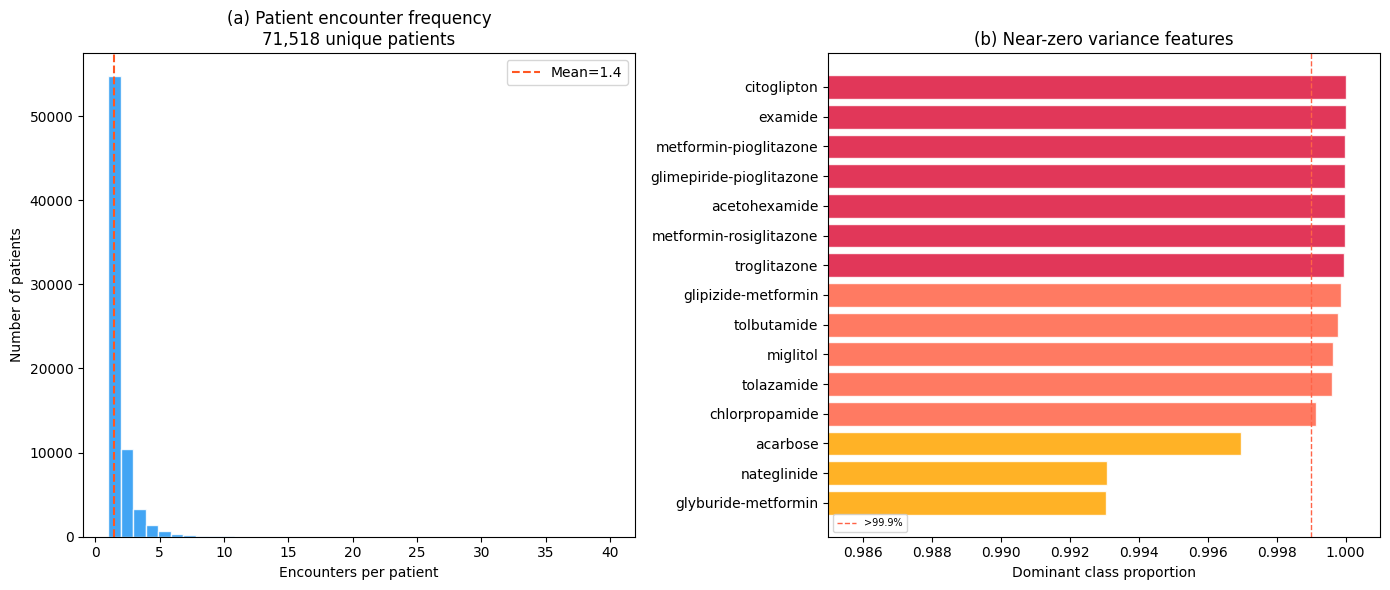

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LG)

# per-patient encounter frequency
enc_per_patient = df_raw.groupby('patient_nbr').size()
axes[0].hist(enc_per_patient, bins=40, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(enc_per_patient.mean(), color=COLORS[1], linestyle='--',
                label=f'Mean={enc_per_patient.mean():.1f}')
axes[0].set_xlabel('Encounters per patient')
axes[0].set_ylabel('Number of patients')
axes[0].set_title(f'(a) Patient encounter frequency\n'
                  f'{df_raw["patient_nbr"].nunique():,} unique patients')
axes[0].legend()

dom_props_all = {}
dom_vals_all  = {}
for col in df_raw.columns:
    if col in ['encounter_id', 'patient_nbr', 'readmitted']:
        continue
    vc = df_raw[col].value_counts(normalize=True)
    if not vc.empty:
        dom_props_all[col] = vc.iloc[0]
        dom_vals_all[col]  = vc.index[0]

# filtering for only > 99%
dom_series_all = pd.Series(dom_props_all).sort_values(ascending=True)
dom_series_filtered = dom_series_all[dom_series_all > 0.99]

bar_colors = []
for v in dom_series_filtered.values:
    if   v > 0.9999: bar_colors.append('crimson')
    elif v > 0.999:  bar_colors.append('tomato')
    elif v > 0.99:   bar_colors.append('orange')
    else:            bar_colors.append(COLORS[2])

# plot
axes[1].barh(dom_series_filtered.index, dom_series_filtered.values,
             color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].axvline(0.999, color='tomato',  linestyle='--', linewidth=1.0,
                label='>99.9%')


# adjusting x-axis to 0.985 and above
axes[1].set_xlim(0.985, 1.001)
axes[1].set_xlabel('Dominant class proportion')
axes[1].set_title('(b) Near-zero variance features')
axes[1].legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.savefig(FIGDIR + 'Fig05_variance_check.png', dpi=150, bbox_inches='tight')
plt.show()


## Task 2 — Data Assembly & Pre-processing

### 2.1-2.2 Data Assembly and Pre-Processing

Cleaning: Applied once, before pipeline.

In [18]:
df_clean = df_raw.copy()

# recode ? to NaN
df_clean.replace('?', np.nan, inplace=True)

# recode sentinel integer codes to NaN
hidden_null_map = {
    'admission_type_id':        [5, 6, 8],
    'discharge_disposition_id': [18, 25, 26],
    'admission_source_id':      [9, 15, 17, 20, 21]
}
for col, codes in hidden_null_map.items():
    df_clean[col] = df_clean[col].replace(codes, np.nan)

# recode None in clinical tests — medically informative, not missing
df_clean['max_glu_serum'] = df_clean['max_glu_serum'].replace('None', 'Not_Tested')
df_clean['A1Cresult']     = df_clean['A1Cresult'].replace('None', 'Not_Tested')

# structural fill for diag_2/3 — absence determined by number_diagnoses
df_clean['diag_2'] = df_clean['diag_2'].fillna('None')
df_clean['diag_3'] = df_clean['diag_3'].fillna('None')

# add missingness indicators before imputation
for col in ['race','admission_type_id','discharge_disposition_id','admission_source_id']:
    df_clean[f'{col}_missing'] = df_clean[col].isnull().astype(int)

print('Cleaning complete.')
print('Missingness indicators added for:', [c for c in df_clean.columns if '_missing' in c])
print('diag_2 None count:', (df_clean['diag_2'] == 'None').sum())
print('diag_3 None count:', (df_clean['diag_3'] == 'None').sum())

Cleaning complete.
Missingness indicators added for: ['race_missing', 'admission_type_id_missing', 'discharge_disposition_id_missing', 'admission_source_id_missing']
diag_2 None count: 358
diag_3 None count: 1423


Defining ICD-9 codes:

In [19]:
#mapping based on Strack et al. (2014)
def icd9_category(code):
    """Map ICD-9 code string to one of 12 clinical categories (Strack et al. 2014)."""
    if pd.isna(code) or str(code).strip() == '':
        return 'Other'
    code = str(code).strip()
    # checking structural absence
    if code == 'None':
        return 'No_Diagnosis'
    if code.startswith('V') or code.startswith('E'):
        return 'E_V_codes'
    try:
        num = float(code.split('.')[0])
    except ValueError:
        return 'Other'
    if 250 <= num <= 250.99:                          return 'Diabetes'
    elif 390 <= num <= 459 or num == 785:             return 'Circulatory'
    elif 460 <= num <= 519 or num == 786:             return 'Respiratory'
    elif 520 <= num <= 579 or num == 787:             return 'Digestive'
    elif 800 <= num <= 999:                           return 'Injury'
    elif 710 <= num <= 739:                           return 'Musculoskeletal'
    elif 580 <= num <= 629 or num == 788:             return 'Genitourinary'
    elif 140 <= num <= 239:                           return 'Neoplasms'
    elif (240 <= num <= 249) or (251 <= num <= 279):  return 'Endocrine_Metabolic'
    elif 280 <= num <= 289:                           return 'Blood_Disorders'
    elif 1   <= num <= 139:                           return 'Infectious_Parasitic'
    else:                                             return 'Other'

for diag_col in ['diag_1','diag_2','diag_3']:
    df_clean[diag_col] = df_clean[diag_col].apply(icd9_category)

# Age ordinal encoding
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
             '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']
age_map = {age: i for i, age in enumerate(age_order)}
df_clean['age'] = df_clean['age'].map(age_map)

print('ICD-9 encoding complete.')
print('diag_1 categories:', df_clean['diag_1'].value_counts().to_dict())

ICD-9 encoding complete.
diag_1 categories: {'Circulatory': 30437, 'Respiratory': 14423, 'Other': 9975, 'Digestive': 9475, 'Diabetes': 8757, 'Injury': 6974, 'Genitourinary': 5117, 'Musculoskeletal': 4957, 'Neoplasms': 3433, 'Infectious_Parasitic': 2768, 'Endocrine_Metabolic': 2702, 'E_V_codes': 1645, 'Blood_Disorders': 1103}


In [20]:
print('diag_1 categories:', df_clean['diag_1'].value_counts().to_dict())
print('diag_2 categories:', df_clean['diag_2'].value_counts().to_dict())
print('diag_3 categories:', df_clean['diag_3'].value_counts().to_dict())

diag_1 categories: {'Circulatory': 30437, 'Respiratory': 14423, 'Other': 9975, 'Digestive': 9475, 'Diabetes': 8757, 'Injury': 6974, 'Genitourinary': 5117, 'Musculoskeletal': 4957, 'Neoplasms': 3433, 'Infectious_Parasitic': 2768, 'Endocrine_Metabolic': 2702, 'E_V_codes': 1645, 'Blood_Disorders': 1103}
diag_2 categories: {'Circulatory': 31881, 'Diabetes': 12794, 'Other': 10937, 'Respiratory': 10895, 'Genitourinary': 8376, 'Endocrine_Metabolic': 8223, 'Digestive': 4170, 'Blood_Disorders': 2926, 'Neoplasms': 2547, 'E_V_codes': 2536, 'Injury': 2428, 'Infectious_Parasitic': 1931, 'Musculoskeletal': 1764, 'No_Diagnosis': 358}
diag_3 categories: {'Circulatory': 30306, 'Diabetes': 17157, 'Other': 10635, 'Endocrine_Metabolic': 9151, 'Respiratory': 7358, 'Genitourinary': 6680, 'E_V_codes': 5058, 'Digestive': 3930, 'Blood_Disorders': 2490, 'Injury': 1946, 'Musculoskeletal': 1915, 'Infectious_Parasitic': 1861, 'Neoplasms': 1856, 'No_Diagnosis': 1423}


Exclusion of death and hospice discharges and target binarisation, as well as extraction of patient_nbr and race:

In [21]:
# inspecting hospice vs home readmission rates
print('Readmission rate by discharge group:')
for name, ids in [('Home (ID 1)', [1]),
                   ('Hospice (ID 13,14)', [13,14]),
                   ('Death (ID 11)', [11])]:
    subset = df_raw[df_raw['discharge_disposition_id'].isin(ids)]
    rate   = (subset['readmitted'] != 'NO').mean()*100 if len(subset) else 0
    print(f'  {name}: n={len(subset):,}, readmission rate={rate:.1f}%')

# excluding death and hospice (Table 4)
exclude_ids = [11, 13, 14, 19, 20, 21]
df_asm = df_clean[~df_clean['discharge_disposition_id'].isin(exclude_ids)].copy()
print(f'\nExcluded {len(df_clean)-len(df_asm):,} encounters (death/hospice)')
print(f'Remaining: {len(df_asm):,}')

# Binarise target
df_asm['target'] = (df_asm['readmitted'] != 'NO').astype(int)
print(f'\nBinarised: {(df_asm["target"]==0).mean()*100:.1f}% not-readmitted / '
      f'{(df_asm["target"]==1).mean()*100:.1f}% readmitted')

# Extract groups and race before dropping
groups_full = df_asm['patient_nbr'].copy()
race_full   = df_asm['race'].copy()

Readmission rate by discharge group:
  Home (ID 1): n=60,234, readmission rate=45.0%
  Hospice (ID 13,14): n=771, readmission rate=11.2%
  Death (ID 11): n=1,642, readmission rate=0.0%

Excluded 2,423 encounters (death/hospice)
Remaining: 99,343

Binarised: 52.9% not-readmitted / 47.1% readmitted


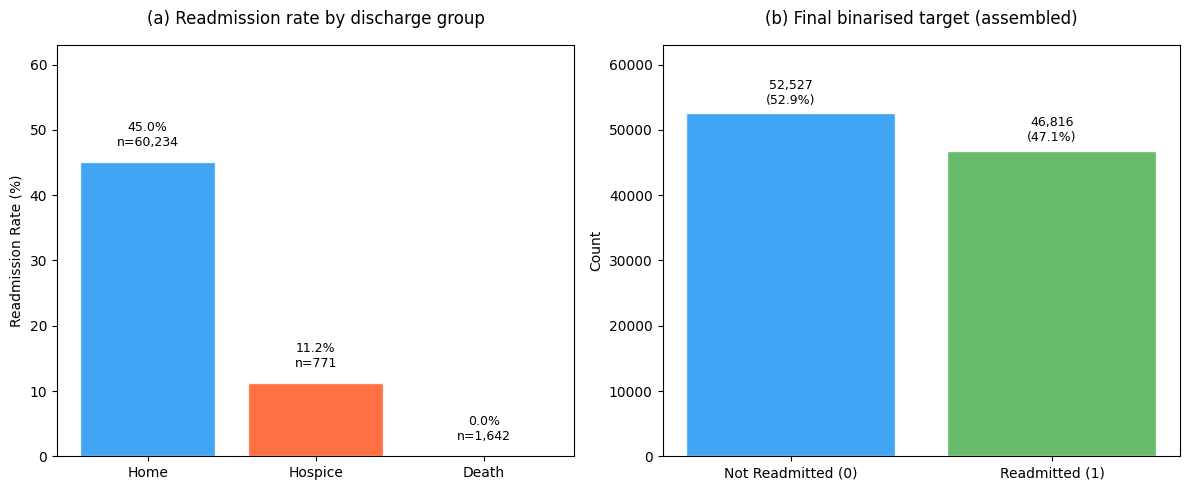

In [22]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_MED)

# (a) Readmission rate by discharge group
disch_groups = [
    ('Home', [1]),
    ('Hospice', [13, 14]),
    ('Death', [11])
]

names, rates, counts = [], [], []
for name, ids in disch_groups:
    subset = df_raw[df_raw['discharge_disposition_id'].isin(ids)]
    rate = (subset['readmitted'] != 'NO').mean() * 100 if len(subset) else 0
    names.append(name)
    rates.append(rate)
    counts.append(len(subset))

axes[0].bar(names, rates, color=COLORS[:3], edgecolor='white', alpha=0.85)
for i, v in enumerate(rates):
    axes[0].text(i, v + 2, f'{v:.1f}%\nn={counts[i]:,}',
                 ha='center', va='bottom', fontsize=9)

axes[0].set_title('(a) Readmission rate by discharge group', pad=15)
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].set_ylim(0, max(rates) * 1.4 if max(rates) > 0 else 100)

# (b) Binarised target distribution (df_asm)
vc_asm = df_asm['target'].value_counts().sort_index()
labels_asm = ['Not Readmitted (0)', 'Readmitted (1)']
axes[1].bar(labels_asm, vc_asm.values, color=[COLORS[0], COLORS[2]], edgecolor='white', alpha=0.85)

for i, v in enumerate(vc_asm.values):
    axes[1].text(i, v + (vc_asm.max()*0.02), f'{v:,}\n({v/len(df_asm)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

axes[1].set_title('(b) Final binarised target (assembled)', pad=15)
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, vc_asm.max() * 1.2)

plt.tight_layout()
plt.savefig(FIGDIR + 'Fig06_target_final.png', dpi=150, bbox_inches='tight')
plt.show()

Encoding:

In [23]:
# binary-encode gender, change, diabetesMed
df_asm['change']      = (df_asm['change'] == 'Ch').astype(int)
df_asm['diabetesMed'] = (df_asm['diabetesMed'] == 'Yes').astype(int)
df_asm['gender']      = (df_asm['gender'] == 'Male').astype(int)

# define feature groups
DROP_HIGH_MISS = ['weight','medical_specialty','payer_code']
DROP_ZERO_VAR  = ['examide','citoglipton','acetohexamide',
                   'metformin-pioglitazone','glimepiride-pioglitazone',
                   'metformin-rosiglitazone','troglitazone',
                   'glipizide-metformin','tolbutamide','miglitol',
                   'tolazamide','chlorpropamide']
DROP_IDS       = ['encounter_id','patient_nbr','readmitted','target']

continuous_features = [
    'time_in_hospital','num_lab_procedures','num_procedures',
    'num_medications','number_outpatient','number_emergency',
    'number_inpatient','number_diagnoses'
]
age_feature = ['age']
ordinal_categorical = [
    'race','diag_1','diag_2','diag_3',
    'max_glu_serum','A1Cresult',
    'metformin','repaglinide','nateglinide','glimepiride',
    'glipizide','glyburide','pioglitazone','rosiglitazone',
    'acarbose','insulin','glyburide-metformin'
]
admin_features = ['admission_type_id','discharge_disposition_id','admission_source_id']
binary_features = [
    'change','diabetesMed','gender',
    'race_missing','admission_type_id_missing',
    'discharge_disposition_id_missing','admission_source_id_missing'
]

print('Feature group sizes:')
print(f'  Continuous:           {len(continuous_features)}')
print(f'  Age (ordinal int):    {len(age_feature)}')
print(f'  Ordinal categorical:  {len(ordinal_categorical)}')
print(f'  Admin IDs:            {len(admin_features)}')
print(f'  Binary/indicators:    {len(binary_features)}')
print(f'  Total: {len(continuous_features)+len(age_feature)+len(ordinal_categorical)+len(admin_features)+len(binary_features)}')

Feature group sizes:
  Continuous:           8
  Age (ordinal int):    1
  Ordinal categorical:  17
  Admin IDs:            3
  Binary/indicators:    7
  Total: 36


Stratified subset and zero patient-leakage check:

In [24]:
# building X and y from full dataset
all_drop = DROP_HIGH_MISS + DROP_ZERO_VAR + DROP_IDS
X_full   = df_asm.drop(columns=all_drop, errors='ignore')
y_full   = df_asm['target'].values

# extracting stratified 20k subset preserving natural class ratio
N_SUBSET  = 20000
pos_ratio = y_full.mean()
n_pos     = int(N_SUBSET * pos_ratio)
n_neg     = N_SUBSET - n_pos

np.random.seed(42)
idx_pos   = np.where(y_full == 1)[0]
idx_neg   = np.where(y_full == 0)[0]
idx_pos_s = resample(idx_pos, n_samples=n_pos, replace=False, random_state=42)
idx_neg_s = resample(idx_neg, n_samples=n_neg, replace=False, random_state=42)
idx_sub   = np.concatenate([idx_pos_s, idx_neg_s])

X      = X_full.iloc[idx_sub].reset_index(drop=True)
y      = y_full[idx_sub]
groups = groups_full.iloc[idx_sub].reset_index(drop=True).values
race_s = race_full.iloc[idx_sub].reset_index(drop=True)

print(f'Subset: {len(y):,} encounters')
print(f'Unique patients: {pd.Series(groups).nunique():,}')
print(f'Class ratio: {(y==0).mean():.3f}/{(y==1).mean():.3f}')

# Verify 0 shared patients
outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
print('\nPatient exclusivity check:')
for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y, groups)):
    shared = len(set(groups[tr_idx]) & set(groups[te_idx]))
    print(f'  Fold {fold+1}: train={len(tr_idx):,}, test={len(te_idx):,}, shared={shared}')

Subset: 20,000 encounters
Unique patients: 18,036
Class ratio: 0.529/0.471

Patient exclusivity check:
  Fold 1: train=15,948, test=4,052, shared=0
  Fold 2: train=16,016, test=3,984, shared=0
  Fold 3: train=16,039, test=3,961, shared=0
  Fold 4: train=15,991, test=4,009, shared=0
  Fold 5: train=16,006, test=3,994, shared=0


In [25]:
print((df_asm['gender'] == 'Unknown/Invalid').sum())

0


Fig 6: readmission rates by discharge group (justifying drop), binarised target distribution after removal of death/hospice discharges, and distribution of target after stratified subsampling:

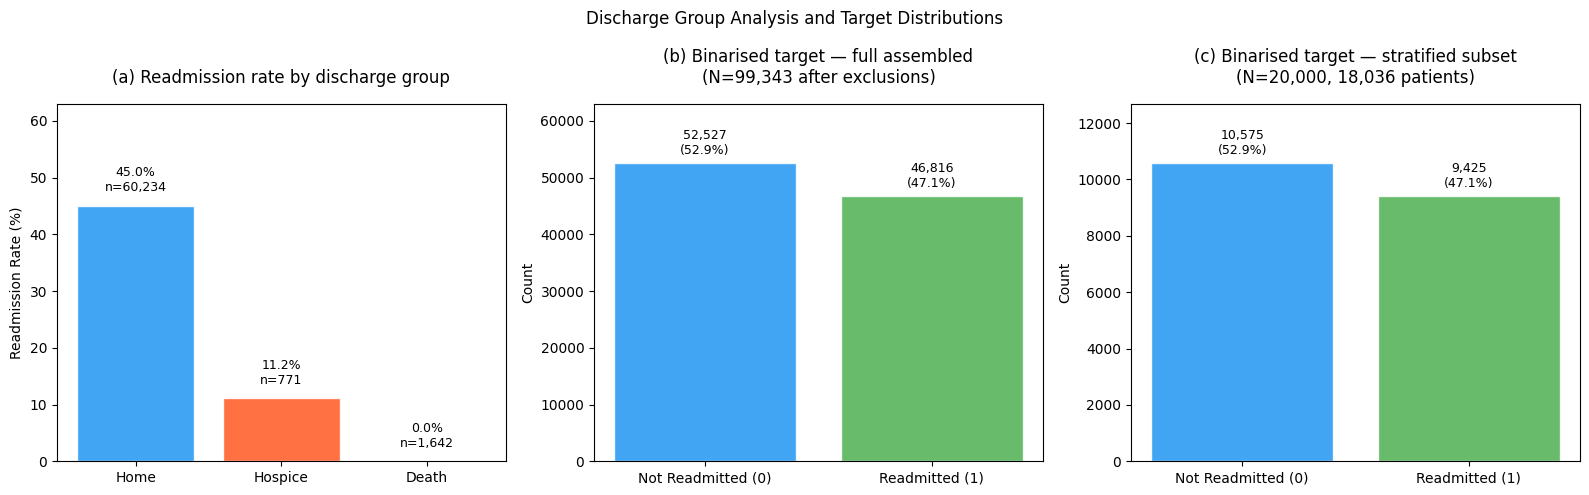

Readmission rates:
  Home      : 45.0%  (n=60,234)
  Hospice   : 11.2%  (n=771)
  Death     : 0.0%  (n=1,642)

Full assembled:  99,343 encounters, 47.1% readmitted
Stratified subset: 20,000 encounters, 47.1% readmitted, 18,036 unique patients


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# readmission rate by discharge group
disch_groups = [
    ('Home', [1]),
    ('Hospice', [13, 14]),
    ('Death', [11])
]

names, rates, counts = [], [], []
for name, ids in disch_groups:
    subset = df_raw[df_raw['discharge_disposition_id'].isin(ids)]
    rate = (subset['readmitted'] != 'NO').mean() * 100 if len(subset) else 0
    names.append(name)
    rates.append(rate)
    counts.append(len(subset))

axes[0].bar(names, rates, color=COLORS[:3], edgecolor='white', alpha=0.85)
for i, v in enumerate(rates):
    axes[0].text(i, v + 2, f'{v:.1f}%\nn={counts[i]:,}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('(a) Readmission rate by discharge group', pad=15)
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].set_ylim(0, max(rates) * 1.4 if max(rates) > 0 else 100)

# binarised target distribution (full assembled dataset)
vc_asm = df_asm['target'].value_counts().sort_index()
labels_asm = ['Not Readmitted (0)', 'Readmitted (1)']
axes[1].bar(labels_asm, vc_asm.values,
            color=[COLORS[0], COLORS[2]], edgecolor='white', alpha=0.85)
for i, v in enumerate(vc_asm.values):
    axes[1].text(i, v + (vc_asm.max()*0.02),
                 f'{v:,}\n({v/len(df_asm)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('(b) Binarised target — full assembled\n'
                  f'(N={len(df_asm):,} after exclusions)', pad=15)
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, vc_asm.max() * 1.2)

# subsampled dataset distribution
vc_sub = pd.Series(y).value_counts().sort_index()
axes[2].bar(labels_asm, vc_sub.values,
            color=[COLORS[0], COLORS[2]], edgecolor='white', alpha=0.85)
for i, v in enumerate(vc_sub.values):
    axes[2].text(i, v + (vc_sub.max()*0.02),
                 f'{v:,}\n({v/len(y)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[2].set_title('(c) Binarised target — stratified subset\n'
                  f'(N={len(y):,}, {pd.Series(groups).nunique():,} patients)',
                  pad=15)
axes[2].set_ylabel('Count')
axes[2].set_ylim(0, vc_sub.max() * 1.2)

plt.suptitle('Discharge Group Analysis and Target Distributions',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig_assembly.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Readmission rates:')
for name, rate, count in zip(names, rates, counts):
    print(f'  {name:<10}: {rate:.1f}%  (n={count:,})')
print(f'\nFull assembled:  {len(df_asm):,} encounters, '
      f'{(df_asm["target"]==1).mean()*100:.1f}% readmitted')
print(f'Stratified subset: {len(y):,} encounters, '
      f'{(y==1).mean()*100:.1f}% readmitted, '
      f'{pd.Series(groups).nunique():,} unique patients')

###2.3 Diagnosis Encoding Visualisation

Fig 7: Plotting ICD-9 category distribution across primary, secondary, and tertiary diagnoses

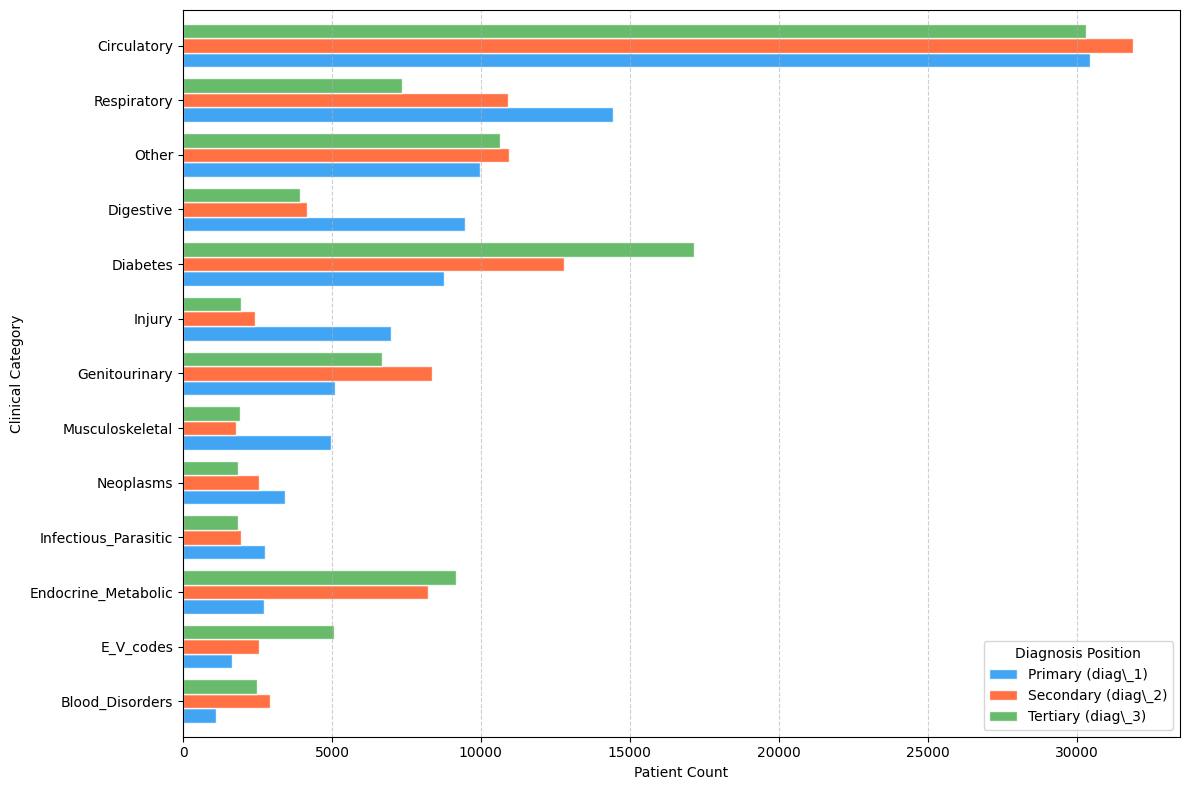

In [ ]:
# plotting ICD-9 category distribution across diag_1/2/3
d1 = df_clean['diag_1'].value_counts()
d2 = df_clean['diag_2'].value_counts()
d3 = df_clean['diag_3'].value_counts()

diag_counts = pd.DataFrame({
    'Primary (diag\_1)':   d1,
    'Secondary (diag\_2)': d2,
    'Tertiary (diag\_3)':  d3
}).fillna(0)

# drop No_Diagnosis — structural absence, not a clinical category
diag_counts = diag_counts.drop('No_Diagnosis', errors='ignore')

# sorting by primary diagnosis frequency
diag_counts = diag_counts.sort_values(by='Primary (diag\_1)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
diag_counts.plot(kind='barh', ax=ax, width=0.8,
                 color=[COLORS[0], COLORS[1], COLORS[2]],
                 edgecolor='white', alpha=0.85)

ax.set_xlabel('Patient Count')
ax.set_ylabel('Clinical Category')
ax.legend(title='Diagnosis Position')
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(FIGDIR + 'Fig06_icd9_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Building ColumnTransformer preprocessor:

In [ ]:
cont_in_X    = [c for c in continuous_features  if c in X.columns]
age_in_X     = [c for c in age_feature           if c in X.columns]
ordinal_in_X = [c for c in ordinal_categorical   if c in X.columns]
admin_in_X   = [c for c in admin_features        if c in X.columns]
binary_in_X  = [c for c in binary_features       if c in X.columns]

preprocessor = ColumnTransformer(transformers=[
    ('continuous', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), cont_in_X),
    ('age', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), age_in_X),
    ('ordinal_cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            handle_unknown='use_encoded_value', unknown_value=-1)),
        ('scaler',  StandardScaler())
    ]), ordinal_in_X),
    ('admin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            handle_unknown='use_encoded_value', unknown_value=-1)),
        ('scaler',  StandardScaler())
    ]), admin_in_X),
    ('binary', 'passthrough', binary_in_X),
], remainder='drop')

print('ColumnTransformer built.')
print(f'Total features entering preprocessor: {X.shape[1]}')

ColumnTransformer built.
Total features entering preprocessor: 36


## Task 3 — Machine Learning Pipeline

### 3.2 Model definitions and hyperparameter grids

In [ ]:
# LinearSVC wrapped in CalibratedClassifierCV for probability output
svm_base = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
svm_cal  = CalibratedClassifierCV(svm_base, method='sigmoid', cv=3)

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# HistGradientBoostingClassifier - supports class_weight, MIA, faster
gb = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)

# Pipelines
pipe_svm = Pipeline([('pre', preprocessor), ('clf', svm_cal)])
pipe_rf  = Pipeline([('pre', preprocessor), ('clf', rf)])
pipe_gb  = Pipeline([('pre', preprocessor), ('clf', gb)])

# Hyperparameter grids
# SVM: 5 candidates
param_svm = {'clf__estimator__C': [1e-3, 1e-2, 1e-1, 1, 10]}

# RF: 24 candidates (2 x 3 x 2 x 2)
param_rf = {
    'clf__n_estimators':      [100, 200],
    'clf__max_depth':         [5, 10],
    'clf__min_samples_leaf':  [1, 5],
    'clf__max_features':      ['sqrt', 'log2']
}

# GB: 12 candidates (2 x 3 x 2)
param_gb = {
    'clf__max_iter':      [100, 200],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__max_depth':     [3, 5]
}

# Total minimum fits: 5 outer x 3 inner x (5+24+12) = 5 x 3 x 41 = 615
print('Models and grids defined.')
print(f'Total minimum fits: 5 x 3 x {5+24+12} = {5*3*(5+24+12)}')

Models and grids defined.
Total minimum fits: 5 x 3 x 41 = 615


### 3.2 Implementation of ML pipeline  that optimizes the models' hyperparameters and provides multiple estimation of test performance

Nested CV helper function:

In [ ]:
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

def compute_metrics(y_true, y_prob, y_pred):
    return {
        'auc':       roc_auc_score(y_true, y_prob),
        'pr_auc':    average_precision_score(y_true, y_prob),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'bal_acc':   balanced_accuracy_score(y_true, y_pred),
        'brier':     brier_score_loss(y_true, y_prob)
    }

def run_nested_cv(pipe, param_grid, X, y, groups,
                  outer_cv, inner_cv, model_name='Model'):
    """
    Nested CV: outer loop = test performance estimation,
    inner loop = hyperparameter selection via GridSearchCV.
    Full val metrics computed by refitting best estimator on
    each inner fold independently — no leakage.
    """
    fold_test_metrics = []
    fold_val_metrics  = []
    best_params_list  = []

    print(f'\n{"="*60}')
    print(f'Nested CV: {model_name}')
    print(f'{"="*60}')

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X, y, groups)):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx],      y[te_idx]
        g_tr       = groups[tr_idx]

        # Inner loop: hyperparameter selection
        gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                          scoring='roc_auc', n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr, groups=g_tr)
        best_params_list.append(gs.best_params_)

        # full val metrics: refit best estimator on each
        # inner fold and evaluate on inner val partition
        inner_fold_metrics = []
        for in_tr, in_val in inner_cv.split(X_tr, y_tr, g_tr):
            est = clone(gs.best_estimator_)
            est.fit(X_tr.iloc[in_tr], y_tr[in_tr])
            y_val_prob = est.predict_proba(X_tr.iloc[in_val])[:, 1]
            y_val_pred = est.predict(X_tr.iloc[in_val])
            inner_fold_metrics.append(
                compute_metrics(y_tr[in_val], y_val_prob, y_val_pred))

        # average across inner folds
        val_avg = {k: np.mean([m[k] for m in inner_fold_metrics])
                   for k in inner_fold_metrics[0].keys()}
        fold_val_metrics.append(val_avg)

        # outer test metrics
        y_prob = gs.predict_proba(X_te)[:, 1]
        y_pred = gs.predict(X_te)
        metrics = compute_metrics(y_te, y_prob, y_pred)
        fold_test_metrics.append(metrics)

        print(f'  Fold {fold+1}: '
              f'val_AUC={val_avg["auc"]:.4f} | '
              f'test_AUC={metrics["auc"]:.4f} | '
              f'Recall={metrics["recall"]:.4f} | '
              f'best_params={gs.best_params_}')

    # aggregation and display
    metric_keys = list(fold_test_metrics[0].keys())
    results = {}
    for k in metric_keys:
        test_vals = [m[k] for m in fold_test_metrics]
        val_vals  = [m[k] for m in fold_val_metrics]
        results[k] = {
            'mean': np.mean(test_vals),
            'std':  np.std(test_vals),
            'vals': test_vals
        }
        results[f'val_{k}'] = {
            'mean': np.mean(val_vals),
            'std':  np.std(val_vals),
            'vals': val_vals
        }

    print(f'\n{"─"*40}')
    print(f'{"Metric":<12} {"Val mean±SD":>16} {"Test mean±SD":>16}')
    print(f'{"─"*40}')
    for k in metric_keys:
        print(f'{k:<12} '
              f'{results[f"val_{k}"]["mean"]:>8.4f}±{results[f"val_{k}"]["std"]:.4f} '
              f'{results[k]["mean"]:>8.4f}±{results[k]["std"]:.4f}')

    return results, best_params_list

Running Nested CV:

In [ ]:
#running nested CV
import pickle, time
t0 = time.time()

results_svm, params_svm = run_nested_cv(
    pipe_svm, param_svm, X, y, groups, outer_cv, inner_cv, 'LinearSVM')
with open(SAVE_DIR + 'results_svm.pkl', 'wb') as f:
    pickle.dump({'results': results_svm, 'params': params_svm}, f)
print(f'SVM saved')

results_rf, params_rf = run_nested_cv(
    pipe_rf, param_rf, X, y, groups, outer_cv, inner_cv, 'Random Forest')
with open(SAVE_DIR + 'results_rf.pkl', 'wb') as f:
    pickle.dump({'results': results_rf, 'params': params_rf}, f)
print(f'RF saved')

results_gb, params_gb = run_nested_cv(
    pipe_gb, param_gb, X, y, groups, outer_cv, inner_cv, 'Gradient Boosting')
with open(SAVE_DIR + 'results_gb.pkl', 'wb') as f:
    pickle.dump({'results': results_gb, 'params': params_gb}, f)
print(f'GB saved')


Nested CV: LinearSVM
  Fold 1: val_AUC=0.6526 | test_AUC=0.6709 | Recall=0.4716 | best_params={'clf__estimator__C': 0.01}
  Fold 2: val_AUC=0.6565 | test_AUC=0.6578 | Recall=0.4546 | best_params={'clf__estimator__C': 0.01}
  Fold 3: val_AUC=0.6592 | test_AUC=0.6467 | Recall=0.4497 | best_params={'clf__estimator__C': 0.01}
  Fold 4: val_AUC=0.6591 | test_AUC=0.6514 | Recall=0.4524 | best_params={'clf__estimator__C': 0.01}
  Fold 5: val_AUC=0.6564 | test_AUC=0.6614 | Recall=0.4581 | best_params={'clf__estimator__C': 0.001}

────────────────────────────────────────
Metric            Val mean±SD     Test mean±SD
────────────────────────────────────────
auc            0.6568±0.0024   0.6576±0.0083
pr_auc         0.6320±0.0046   0.6328±0.0161
recall         0.4555±0.0128   0.4573±0.0077
precision      0.6222±0.0030   0.6227±0.0208
f1             0.5258±0.0094   0.5273±0.0123
bal_acc        0.6045±0.0029   0.6053±0.0078
brier          0.2298±0.0004   0.2296±0.0013
SVM saved

Nested CV: Rando

### 3.5 Performance summary table

See below for 3.4

In [ ]:
for name, results in [('L.SVM', results_svm),
                       ('R.Forest', results_rf),
                       ('G.Boost', results_gb)]:
    print(f'\n{name}:')
    print(f'  Val  | '
          f'AUC={results["val_auc"]["mean"]:.3f}±{results["val_auc"]["std"]:.3f} | '
          f'PR-AUC={results["val_pr_auc"]["mean"]:.3f}±{results["val_pr_auc"]["std"]:.3f} | '
          f'Rec={results["val_recall"]["mean"]:.3f}±{results["val_recall"]["std"]:.3f} | '
          f'Prec={results["val_precision"]["mean"]:.3f}±{results["val_precision"]["std"]:.3f} | '
          f'F1={results["val_f1"]["mean"]:.3f}±{results["val_f1"]["std"]:.3f} | '
          f'BalAcc={results["val_bal_acc"]["mean"]:.3f}±{results["val_bal_acc"]["std"]:.3f}')
    print(f'  Test | '
          f'AUC={results["auc"]["mean"]:.3f}±{results["auc"]["std"]:.3f} | '
          f'PR-AUC={results["pr_auc"]["mean"]:.3f}±{results["pr_auc"]["std"]:.3f} | '
          f'Rec={results["recall"]["mean"]:.3f}±{results["recall"]["std"]:.3f} | '
          f'Prec={results["precision"]["mean"]:.3f}±{results["precision"]["std"]:.3f} | '
          f'F1={results["f1"]["mean"]:.3f}±{results["f1"]["std"]:.3f} | '
          f'BalAcc={results["bal_acc"]["mean"]:.3f}±{results["bal_acc"]["std"]:.3f}')

# running wilcoxon tests
from scipy.stats import wilcoxon
rf_aucs  = results_rf['auc']['vals']
gb_aucs  = results_gb['auc']['vals']
svm_aucs = results_svm['auc']['vals']

print('\nWilcoxon tests:')
for a, b, label in [(rf_aucs, svm_aucs, 'RF vs SVM'),
                     (gb_aucs, svm_aucs, 'GB vs SVM'),
                     (rf_aucs, gb_aucs,  'RF vs GB')]:
    stat, p = wilcoxon(a, b, alternative='greater')
    r = stat / (len(a)*(len(a)+1)/2)
    print(f'  {label}: W={stat:.0f}, p={p:.3f}, r={r:.2f}')


L.SVM:
  Val  | AUC=0.657±0.002 | PR-AUC=0.632±0.005 | Rec=0.456±0.013 | Prec=0.622±0.003 | F1=0.526±0.009 | BalAcc=0.604±0.003
  Test | AUC=0.658±0.008 | PR-AUC=0.633±0.016 | Rec=0.457±0.008 | Prec=0.623±0.021 | F1=0.527±0.012 | BalAcc=0.605±0.008

R.Forest:
  Val  | AUC=0.675±0.003 | PR-AUC=0.644±0.005 | Rec=0.562±0.007 | Prec=0.611±0.005 | F1=0.585±0.006 | BalAcc=0.621±0.003
  Test | AUC=0.677±0.011 | PR-AUC=0.647±0.017 | Rec=0.564±0.012 | Prec=0.615±0.018 | F1=0.588±0.015 | BalAcc=0.625±0.009

G.Boost:
  Val  | AUC=0.672±0.003 | PR-AUC=0.643±0.005 | Rec=0.565±0.010 | Prec=0.605±0.007 | F1=0.584±0.008 | BalAcc=0.618±0.004
  Test | AUC=0.674±0.011 | PR-AUC=0.647±0.017 | Rec=0.569±0.023 | Prec=0.605±0.022 | F1=0.586±0.023 | BalAcc=0.619±0.014

Wilcoxon tests:
  RF vs SVM: W=15, p=0.031, r=1.00
  GB vs SVM: W=15, p=0.031, r=1.00
  RF vs GB: W=15, p=0.031, r=1.00


###3.4 Performance variation as a function of hyperparameters

In [ ]:
# refit on full 20k for hyperparameter plots
inner_cv_full = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

print('SVM GridSearchCV')
gs_svm_full = GridSearchCV(pipe_svm, param_svm, cv=inner_cv_full,
                            scoring='roc_auc', n_jobs=-1,
                            return_train_score=True)
gs_svm_full.fit(X, y, groups=groups)
print(f'Best SVM: {gs_svm_full.best_params_}')

print('RF GridSearchCV')
gs_rf_full = GridSearchCV(pipe_rf, param_rf, cv=inner_cv_full,
                           scoring='roc_auc', n_jobs=-1,
                           return_train_score=True)
gs_rf_full.fit(X, y, groups=groups)
print(f'Best RF: {gs_rf_full.best_params_}')

print('GB GridSearchCV')
gs_gb_full = GridSearchCV(pipe_gb, param_gb, cv=inner_cv_full,
                           scoring='roc_auc', n_jobs=-1,
                           return_train_score=True)
gs_gb_full.fit(X, y, groups=groups)
print(f'Best GB: {gs_gb_full.best_params_}')

# saving to avoid reruns
with open(SAVE_DIR + 'hyperparameter_gridsearches.pkl', 'wb') as f:
    pickle.dump({
        'gs_svm': gs_svm_full,
        'gs_rf':  gs_rf_full,
        'gs_gb':  gs_gb_full
    }, f)
print('GridSearch objects saved.')

SVM GridSearchCV
Best SVM: {'clf__estimator__C': 0.01}
RF GridSearchCV
Best RF: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
GB GridSearchCV
Best GB: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__max_iter': 100}
GridSearch objects saved.


Fig 8: Hyperparameter analysis

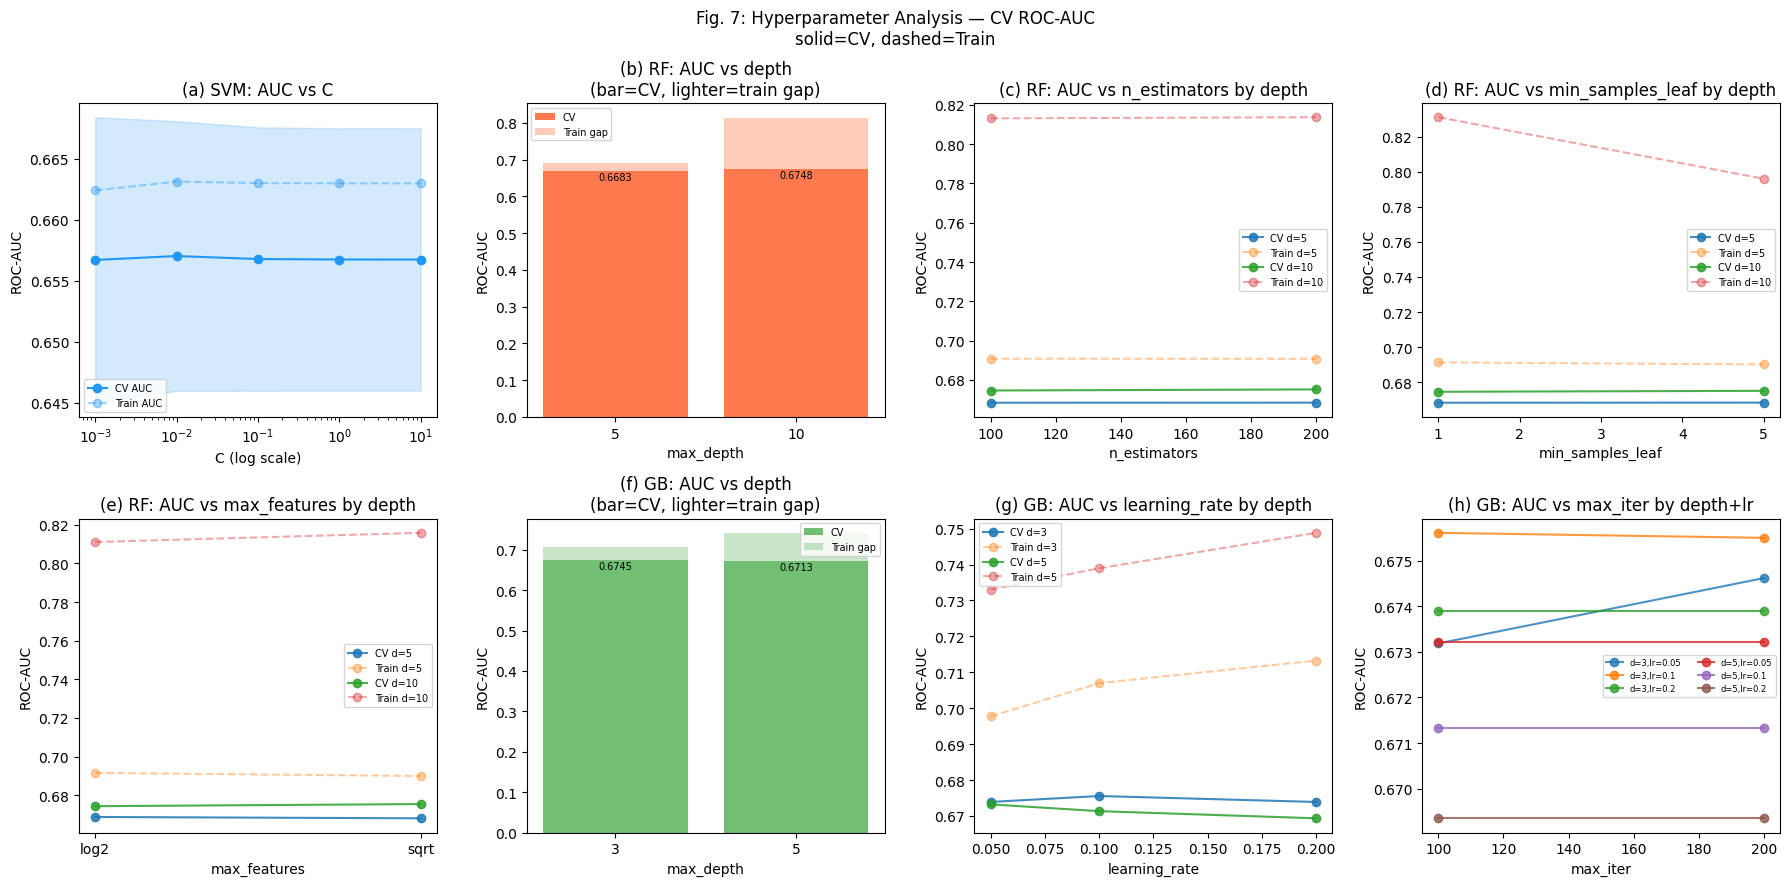

SVM: CV AUC by C
-----------------------------------------------------------------
  C=0.001   : CV=0.6567, Train=0.6624, gap=0.0057
  C=0.01    : CV=0.6570, Train=0.6631, gap=0.0061
  C=0.1     : CV=0.6568, Train=0.6630, gap=0.0062
  C=1.0     : CV=0.6568, Train=0.6630, gap=0.0062
  C=10.0    : CV=0.6567, Train=0.6630, gap=0.0062
  Best: {'clf__estimator__C': 0.01}

RF: CV AUC — all hyperparameters
-----------------------------------------------------------------
   depth  n_est min_leaf max_feat       CV    Train      gap
       5    100        1     sqrt   0.6680   0.6902   0.0222
       5    200        1     sqrt   0.6682   0.6905   0.0223
       5    100        5     sqrt   0.6679   0.6893   0.0214
       5    200        5     sqrt   0.6678   0.6896   0.0218
       5    100        1     log2   0.6685   0.6925   0.0240
       5    200        1     log2   0.6685   0.6919   0.0234
       5    100        5     log2   0.6689   0.6910   0.0221
       5    200        5     log2   0.6688 

In [ ]:
svm_df = pd.DataFrame(gs_svm_full.cv_results_)
rf_df  = pd.DataFrame(gs_rf_full.cv_results_)
gb_df  = pd.DataFrame(gs_gb_full.cv_results_)

# extract params
svm_df['C']           = [p['clf__estimator__C'] for p in svm_df['params']]
rf_df['depth']        = [p['clf__max_depth'] for p in rf_df['params']]
rf_df['n_est']        = [p['clf__n_estimators'] for p in rf_df['params']]
rf_df['min_leaf']     = [p['clf__min_samples_leaf'] for p in rf_df['params']]
rf_df['max_feat']     = [p['clf__max_features'] for p in rf_df['params']]
gb_df['depth']        = [p['clf__max_depth'] for p in gb_df['params']]
gb_df['lr']           = [p['clf__learning_rate'] for p in gb_df['params']]
gb_df['n_iter']       = [p['clf__max_iter'] for p in gb_df['params']]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# plot (a) SVM: AUC vs C
ax = axes[0, 0]
ax.semilogx(svm_df['C'], svm_df['mean_test_score'],
            'o-', color=COLORS[0], label='CV AUC')
ax.fill_between(svm_df['C'],
    svm_df['mean_test_score'] - svm_df['std_test_score'],
    svm_df['mean_test_score'] + svm_df['std_test_score'],
    alpha=0.2, color=COLORS[0])
ax.semilogx(svm_df['C'], svm_df['mean_train_score'],
            'o--', color=COLORS[0], alpha=0.4, label='Train AUC')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('ROC-AUC')
ax.set_title('(a) SVM: AUC vs C')
ax.legend(fontsize=7)

# plot (b) RF: AUC vs depth
ax = axes[0, 1]
for depth in [5, 10]:
    sub = rf_df[rf_df['depth'] == depth]
    cv_mean    = sub['mean_test_score'].mean()
    train_mean = sub['mean_train_score'].mean()
    ax.bar(str(depth), cv_mean, color=COLORS[1], alpha=0.8,
           label='CV' if depth == 5 else '')
    ax.bar(str(depth), train_mean - cv_mean, bottom=cv_mean,
           color=COLORS[1], alpha=0.3,
           label='Train gap' if depth == 5 else '')
    ax.text(str(depth), cv_mean - 0.002, f'{cv_mean:.4f}',
            ha='center', va='top', fontsize=7)
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC-AUC')
ax.set_title('(b) RF: AUC vs depth\n(bar=CV, lighter=train gap)')
ax.legend(fontsize=7)

# plot (c) RF: AUC vs n_estimators by depth
ax = axes[0, 2]
for depth in [5, 10]:
    sub = rf_df[rf_df['depth'] == depth]
    cv_agg    = sub.groupby('n_est')['mean_test_score'].mean()
    train_agg = sub.groupby('n_est')['mean_train_score'].mean()
    ax.plot(cv_agg.index, cv_agg.values, 'o-',
            label=f'CV d={depth}', alpha=0.85)
    ax.plot(train_agg.index, train_agg.values, 'o--',
            label=f'Train d={depth}', alpha=0.4)
ax.set_xlabel('n_estimators')
ax.set_ylabel('ROC-AUC')
ax.set_title('(c) RF: AUC vs n_estimators by depth')
ax.legend(fontsize=7)

# plot (d) RF: AUC vs min_samples_leaf by depth
ax = axes[0, 3]
for depth in [5, 10]:
    sub = rf_df[rf_df['depth'] == depth]
    cv_agg    = sub.groupby('min_leaf')['mean_test_score'].mean()
    train_agg = sub.groupby('min_leaf')['mean_train_score'].mean()
    ax.plot(cv_agg.index, cv_agg.values, 'o-',
            label=f'CV d={depth}', alpha=0.85)
    ax.plot(train_agg.index, train_agg.values, 'o--',
            label=f'Train d={depth}', alpha=0.4)
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('ROC-AUC')
ax.set_title('(d) RF: AUC vs min_samples_leaf by depth')
ax.legend(fontsize=7)

# plot (e) RF: AUC vs max_features by depth
ax = axes[1, 0]
for depth in [5, 10]:
    sub = rf_df[rf_df['depth'] == depth]
    cv_agg    = sub.groupby('max_feat')['mean_test_score'].mean()
    train_agg = sub.groupby('max_feat')['mean_train_score'].mean()
    x = np.arange(len(cv_agg))
    ax.plot(x, cv_agg.values, 'o-',
            label=f'CV d={depth}', alpha=0.85)
    ax.plot(x, train_agg.values, 'o--',
            label=f'Train d={depth}', alpha=0.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(['log2', 'sqrt'])
ax.set_xlabel('max_features')
ax.set_ylabel('ROC-AUC')
ax.set_title('(e) RF: AUC vs max_features by depth')
ax.legend(fontsize=7)

# plot(f) GB: AUC vs depth
ax = axes[1, 1]
for depth in [3, 5]:
    sub = gb_df[gb_df['depth'] == depth]
    cv_mean    = sub['mean_test_score'].mean()
    train_mean = sub['mean_train_score'].mean()
    ax.bar(str(depth), cv_mean, color=COLORS[2], alpha=0.8,
           label='CV' if depth == 3 else '')
    ax.bar(str(depth), train_mean - cv_mean, bottom=cv_mean,
           color=COLORS[2], alpha=0.3,
           label='Train gap' if depth == 3 else '')
    ax.text(str(depth), cv_mean - 0.002, f'{cv_mean:.4f}',
            ha='center', va='top', fontsize=7)
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC-AUC')
ax.set_title('(f) GB: AUC vs depth\n(bar=CV, lighter=train gap)')
ax.legend(fontsize=7)

# plot (g) GB: AUC vs learning_rate by depth
ax = axes[1, 2]
for depth in [3, 5]:
    sub = gb_df[gb_df['depth'] == depth]
    cv_agg    = sub.groupby('lr')['mean_test_score'].mean()
    train_agg = sub.groupby('lr')['mean_train_score'].mean()
    ax.plot(cv_agg.index, cv_agg.values, 'o-',
            label=f'CV d={depth}', alpha=0.85)
    ax.plot(train_agg.index, train_agg.values, 'o--',
            label=f'Train d={depth}', alpha=0.4)
ax.set_xlabel('learning_rate')
ax.set_ylabel('ROC-AUC')
ax.set_title('(g) GB: AUC vs learning_rate by depth')
ax.legend(fontsize=7)

# plot(h) GB: AUC vs n_iter by depth and lr
ax = axes[1, 3]
for depth in [3, 5]:
    for lr in [0.05, 0.1, 0.2]:
        mask = (gb_df['depth'] == depth) & (gb_df['lr'] == lr)
        sub  = gb_df[mask]
        if len(sub) == 0: continue
        cv_agg = sub.groupby('n_iter')['mean_test_score'].mean()
        ax.plot(cv_agg.index, cv_agg.values, 'o-',
                label=f'd={depth},lr={lr}', alpha=0.8)
ax.set_xlabel('max_iter')
ax.set_ylabel('ROC-AUC')
ax.set_title('(h) GB: AUC vs max_iter by depth+lr')
ax.legend(fontsize=6, ncol=2)

plt.suptitle('Fig. 7: Hyperparameter Analysis — CV ROC-AUC\n'
             'solid=CV, dashed=Train', fontsize=12)
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig07_hyperparameter_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# summarise numerically as well as plot for clearer inspection
print('='*65)
print('SVM: CV AUC by C')
print('-'*65)
for _, row in svm_df.iterrows():
    print(f'  C={row["C"]:<8}: CV={row["mean_test_score"]:.4f}, '
          f'Train={row["mean_train_score"]:.4f}, '
          f'gap={row["mean_train_score"]-row["mean_test_score"]:.4f}')
print(f'  Best: {gs_svm_full.best_params_}')

print('\nRF: CV AUC — all hyperparameters')
print('-'*65)
print(f'  {"depth":>6} {"n_est":>6} {"min_leaf":>8} '
      f'{"max_feat":>8} {"CV":>8} {"Train":>8} {"gap":>8}')
for _, row in rf_df.iterrows():
    print(f'  {row["depth"]:>6} {row["n_est"]:>6} {row["min_leaf"]:>8} '
          f'{row["max_feat"]:>8} {row["mean_test_score"]:>8.4f} '
          f'{row["mean_train_score"]:>8.4f} '
          f'{row["mean_train_score"]-row["mean_test_score"]:>8.4f}')
print(f'  Best: {gs_rf_full.best_params_}')

print('\nGB: CV AUC — all hyperparameters')
print('-'*65)
print(f'  {"depth":>6} {"lr":>6} {"n_iter":>8} '
      f'{"CV":>8} {"Train":>8} {"gap":>8}')
for _, row in gb_df.iterrows():
    print(f'  {row["depth"]:>6} {row["lr"]:>6} {row["n_iter"]:>8} '
          f'{row["mean_test_score"]:>8.4f} '
          f'{row["mean_train_score"]:>8.4f} '
          f'{row["mean_train_score"]-row["mean_test_score"]:>8.4f}')
print(f'  Best: {gs_gb_full.best_params_}')

Fig 9: Learning curve analysis

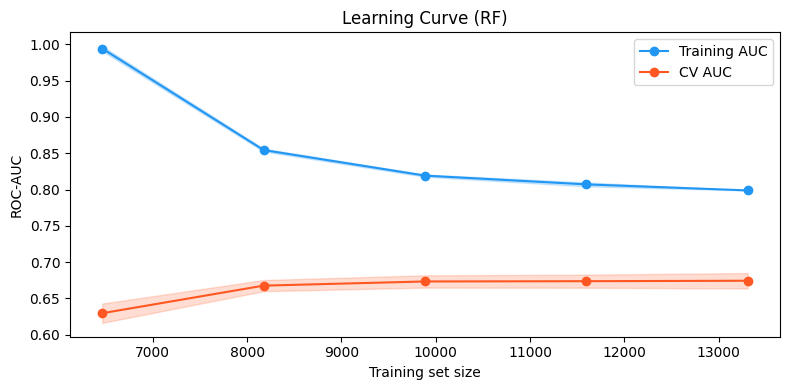

Learning Curve — numerical values:
       N    Train AUC   Train SD     CV AUC      CV SD      Gap
-----------------------------------------------------------------
    1330          nan        nan        nan        nan      nan
    3042          nan        nan        nan        nan      nan
    4753          nan        nan        nan        nan      nan
    6464       0.9940     0.0034     0.6297     0.0133   0.3643
    8175       0.8544     0.0020     0.6677     0.0077   0.1867
    9886       0.8192     0.0016     0.6734     0.0085   0.1457
   11597       0.8071     0.0027     0.6738     0.0090   0.1333
   13309       0.7988     0.0001     0.6744     0.0106   0.1244

Final CV AUC at N=13309: 0.6744
CV AUC improvement N=1330→N=13309: +nan


In [ ]:
# Learning curve for best RF estimator — evaluating whether performance
# is data-limited or feature-determined (high-bias diagnosis). also verifies
# whether subsampling is viable or detrimental to performance
best_rf_pipe = gs_rf_full.best_estimator_

# StratifiedGroupKFold used to maintain patient-level integrity
# consistent with outer CV — prevents within-patient correlation inflating estimates
train_sizes, train_scores, cv_scores = learning_curve(
    best_rf_pipe, X, y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    groups=groups,
    n_jobs=-1
)
# plot training and CV AUC with ±1 SD bands
# convergence of the two curves indicates high-bias regime
fig, ax = plt.subplots(figsize=FIGSIZE_SM)
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-',
        color=COLORS[0], label='Training AUC')
ax.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.2, color=COLORS[0])
ax.plot(train_sizes, cv_scores.mean(axis=1), 'o-',
        color=COLORS[1], label='CV AUC')
ax.fill_between(train_sizes,
    cv_scores.mean(axis=1) - cv_scores.std(axis=1),
    cv_scores.mean(axis=1) + cv_scores.std(axis=1),
    alpha=0.2, color=COLORS[1])
ax.set_xlabel('Training set size')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curve (RF)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig11_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# numerical output to identify plateau point
# gap column confirms train-CV separation at each sample size
print('Learning Curve — numerical values:')
print(f'{"N":>8} {"Train AUC":>12} {"Train SD":>10} {"CV AUC":>10} {"CV SD":>10} {"Gap":>8}')
print('-'*65)
for i, n in enumerate(train_sizes):
    tr_mean = train_scores[i].mean()
    tr_std  = train_scores[i].std()
    cv_mean = cv_scores[i].mean()
    cv_std  = cv_scores[i].std()
    print(f'{n:>8.0f} {tr_mean:>12.4f} {tr_std:>10.4f} '
          f'{cv_mean:>10.4f} {cv_std:>10.4f} {tr_mean-cv_mean:>8.4f}')

print(f'\nFinal CV AUC at N={train_sizes[-1]:.0f}: {cv_scores[-1].mean():.4f}')
print(f'CV AUC improvement N={train_sizes[0]:.0f}→N={train_sizes[-1]:.0f}: '
      f'{cv_scores[-1].mean() - cv_scores[0].mean():+.4f}')

Fig 10: Cost-sensitive threshold analysis

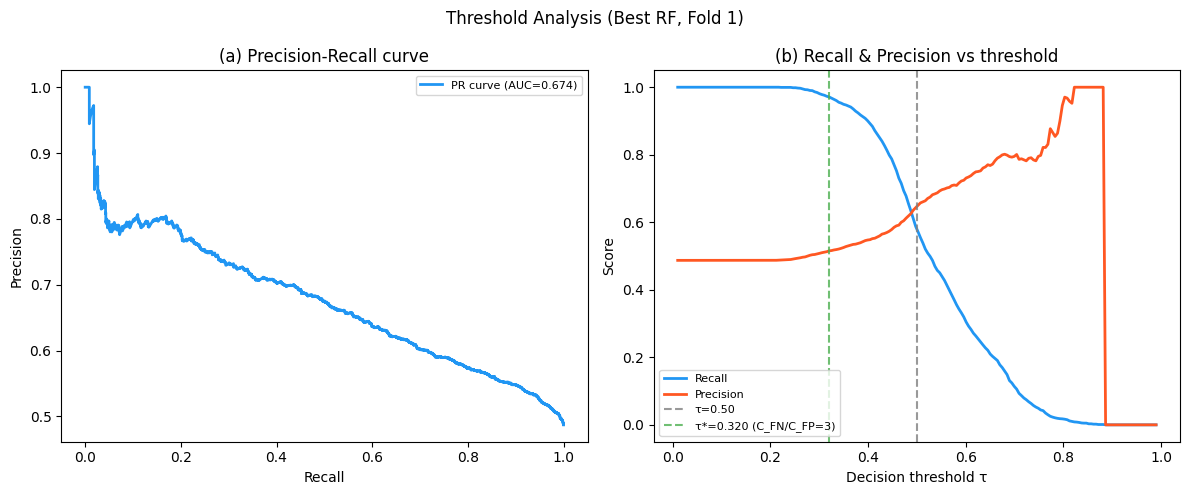

Threshold Analysis — numerical values:
  PR-AUC (fold 1):         0.6743
  Optimal threshold τ*:    0.3203  (C_FN/C_FP=3)
  τ=0.50:  Recall=0.5795, Precision=0.6467, F1=0.6113
  τ*=0.320: Recall=0.9711,  Precision=0.5153, F1=0.6733
  Recall gain:     +0.3916
  Precision cost:  -0.1314


In [ ]:
# Threshold analysis on outer fold 1 — illustrates clinical cost-sensitive
# operating point selection; fold 1 used for visualisation only, not selection
outer_splits = list(outer_cv.split(X, y, groups))
tr_idx, te_idx = outer_splits[0]
best_rf_pipe.fit(X.iloc[tr_idx], y[tr_idx])
y_prob_te = best_rf_pipe.predict_proba(X.iloc[te_idx])[:, 1]
y_true_te = y[te_idx]

# derive optimal threshold by maximising 3×TPR − FPR
# cost ratio CFN/CFP=3 reflects higher clinical cost of missed readmissions
# (illustrative — not used to select the final model)
fpr_arr, tpr_arr, thresholds_roc = roc_curve(y_true_te, y_prob_te)
cost_ratio = 3
objective  = cost_ratio * tpr_arr - fpr_arr
opt_idx    = np.argmax(objective)
tau_star   = thresholds_roc[opt_idx]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_MED)

# (a) PR curve — threshold-independent view of positive-class performance
# PR-AUC reported alongside ROC-AUC in §3.1 as primary metric
precision_arr, recall_arr, _ = precision_recall_curve(y_true_te, y_prob_te)
axes[0].plot(recall_arr, precision_arr, color=COLORS[0], lw=2,
             label=f'PR curve (AUC={average_precision_score(y_true_te, y_prob_te):.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('(a) Precision-Recall curve')
axes[0].legend(fontsize=8)


# (b) recall and precision across all thresholds
# shows the sensitivity/precision trade-off at default tau=0.5 vs cost-optimal tau*
thresh_range = np.linspace(0.01, 0.99, 200)
rec_vals  = [recall_score(y_true_te, (y_prob_te>=t).astype(int), zero_division=0)
             for t in thresh_range]
prec_vals = [precision_score(y_true_te, (y_prob_te>=t).astype(int), zero_division=0)
             for t in thresh_range]

axes[1].plot(thresh_range, rec_vals,  color=COLORS[0], label='Recall',    lw=2)
axes[1].plot(thresh_range, prec_vals, color=COLORS[1], label='Precision', lw=2)
axes[1].axvline(0.5,      color='grey',    linestyle='--', alpha=0.8, label='τ=0.50')
axes[1].axvline(tau_star, color=COLORS[2], linestyle='--', alpha=0.8,
                label=f'τ*={tau_star:.3f} (C_FN/C_FP=3)')
axes[1].set_xlabel('Decision threshold τ')
axes[1].set_ylabel('Score')
axes[1].set_title('(b) Recall & Precision vs threshold')
axes[1].legend(fontsize=8)


# numerical comparison of default vs cost-optimal threshold
# values cited directly in §3.6 results discussion
rec_default  = recall_score(y_true_te, (y_prob_te>=0.5).astype(int))
prec_default = precision_score(y_true_te, (y_prob_te>=0.5).astype(int))
rec_opt      = recall_score(y_true_te, (y_prob_te>=tau_star).astype(int))
prec_opt     = precision_score(y_true_te, (y_prob_te>=tau_star).astype(int))

plt.suptitle('Threshold Analysis (Best RF, Fold 1)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig12_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


# recall gain quantifies clinical benefit of lowering threshold
# precision cost quantifies the trade-off in false positive rate
print('Threshold Analysis — numerical values:')
print(f'  PR-AUC (fold 1):         {average_precision_score(y_true_te, y_prob_te):.4f}')
print(f'  Optimal threshold τ*:    {tau_star:.4f}  (C_FN/C_FP={cost_ratio})')
print(f'  τ=0.50:  Recall={rec_default:.4f}, Precision={prec_default:.4f}, '
      f'F1={2*rec_default*prec_default/(rec_default+prec_default):.4f}')
print(f'  τ*={tau_star:.3f}: Recall={rec_opt:.4f},  Precision={prec_opt:.4f}, '
      f'F1={2*rec_opt*prec_opt/(rec_opt+prec_opt) if (rec_opt+prec_opt)>0 else 0:.4f}')
print(f'  Recall gain:     {rec_opt - rec_default:+.4f}')
print(f'  Precision cost:  {prec_opt - prec_default:+.4f}')

Fig 11: Calibration curve — SVM

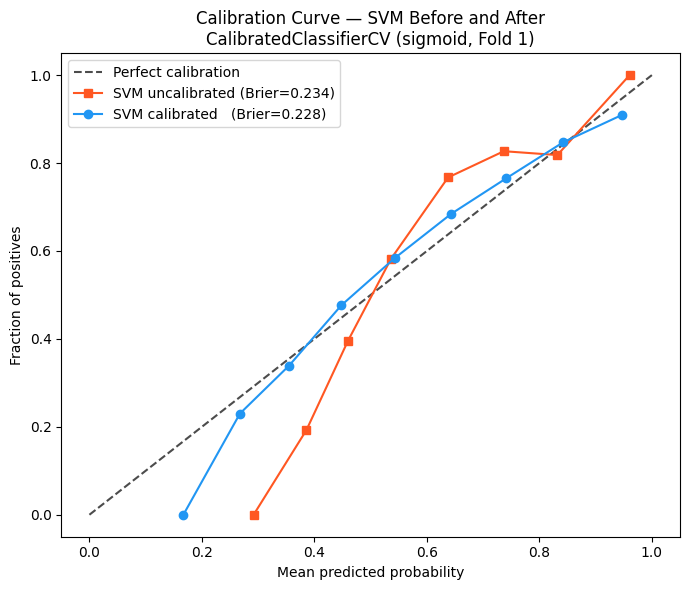

Calibration — numerical values:
  Best C used: 0.01
  Uncalibrated Brier: 0.2344
  Calibrated Brier:   0.2279
  Improvement:        +0.0065

  Calibration curve points (mean_pred → frac_pos):
  Bin     Uncal pred   Uncal frac   Cal pred   Cal frac
  -------------------------------------------------------
  1            0.292        0.000      0.167      0.000
  2            0.386        0.193      0.268      0.230
  3            0.460        0.396      0.355      0.339
  4            0.536        0.582      0.448      0.477
  5            0.638        0.767      0.542      0.583
  6            0.737        0.827      0.643      0.685
  7            0.832        0.818      0.741      0.765
  8            0.960        1.000      0.842      0.847
  9              ---          ---      0.946      0.909


In [ ]:
# Evaluates SVM probability outputs before and after calibration
# on outer fold 1 — fold 1 used for visualisation only
tr_idx, te_idx = outer_splits[0]
X_tr1, X_te1   = X.iloc[tr_idx], X.iloc[te_idx]
y_tr1, y_te1   = y[tr_idx],      y[te_idx]

# use best C from nested CV rather than fixed value
# ensures calibration assessment reflects the tuned model
best_C = gs_svm_full.best_params_.get('clf__estimator__C', 0.01)

# uncalibrated SVM — raw decision function scores converted to
# probabilities via sigmoid (expit); LinearSVC has no native predict_proba
svm_uncal = Pipeline([
    ('pre', preprocessor),
    ('clf', LinearSVC(class_weight='balanced', max_iter=5000,
                      random_state=42, C=best_C))
])
svm_uncal.fit(X_tr1, y_tr1)
df_scores    = svm_uncal.named_steps['clf'].decision_function(
    svm_uncal.named_steps['pre'].transform(X_te1))
y_prob_uncal = expit(df_scores)

# calibrated SVM — CalibratedClassifierCV wraps LinearSVC with
# platt scaling (sigmoid, 3-fold internal CV) to produce reliable
# probability estimates; same approach used in all Task 3 pipelines
svm_cal_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=5000,
                  random_state=42, C=best_C),
        method='sigmoid', cv=3))
])
svm_cal_pipe.fit(X_tr1, y_tr1)
y_prob_cal = svm_cal_pipe.predict_proba(X_te1)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], 'k--', label='Perfect calibration', alpha=0.7)

# calibration_curve bins predicted probabilities and computes
# mean predicted vs actual fraction of positives per bin
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_te1, y_prob_uncal, n_bins=10)
frac_pos_cal,   mean_pred_cal   = calibration_curve(y_te1, y_prob_cal,   n_bins=10)

brier_uncal = brier_score_loss(y_te1, y_prob_uncal)
brier_cal   = brier_score_loss(y_te1, y_prob_cal)

ax.plot(mean_pred_uncal, frac_pos_uncal, 's-', color=COLORS[1],
        label=f'SVM uncalibrated (Brier={brier_uncal:.3f})')
ax.plot(mean_pred_cal,   frac_pos_cal,   'o-', color=COLORS[0],
        label=f'SVM calibrated   (Brier={brier_cal:.3f})')

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — SVM Before and After\n'
             'CalibratedClassifierCV (sigmoid, Fold 1)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig13_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# numerical output — Brier improvement and per-bin breakdown
print('Calibration — numerical values:')
print(f'  Best C used: {best_C}')
print(f'  Uncalibrated Brier: {brier_uncal:.4f}')
print(f'  Calibrated Brier:   {brier_cal:.4f}')
print(f'  Improvement:        {brier_uncal - brier_cal:+.4f}')
print(f'\n  Calibration curve points (mean_pred → frac_pos):')
print(f'  {"Bin":<5} {"Uncal pred":>12} {"Uncal frac":>12} {"Cal pred":>10} {"Cal frac":>10}')
print('  ' + '-'*55)
for i in range(max(len(mean_pred_uncal), len(mean_pred_cal))):
    up = f'{mean_pred_uncal[i]:.3f}' if i < len(mean_pred_uncal) else '---'
    uf = f'{frac_pos_uncal[i]:.3f}' if i < len(frac_pos_uncal) else '---'
    cp = f'{mean_pred_cal[i]:.3f}'  if i < len(mean_pred_cal)   else '---'
    cf = f'{frac_pos_cal[i]:.3f}'   if i < len(frac_pos_cal)    else '---'
    print(f'  {i+1:<5} {up:>12} {uf:>12} {cp:>10} {cf:>10}')

## Task 4 — Model Interpretation

Installing SHAP:

In [ ]:
try:
    import shap
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap
    print(f'SHAP installed: {shap.__version__}')

SHAP version: 0.50.0


###4.1 Relative Feature Importance

Fig 12: Native feature importance (SVM coefficients, RF & GB Gini)

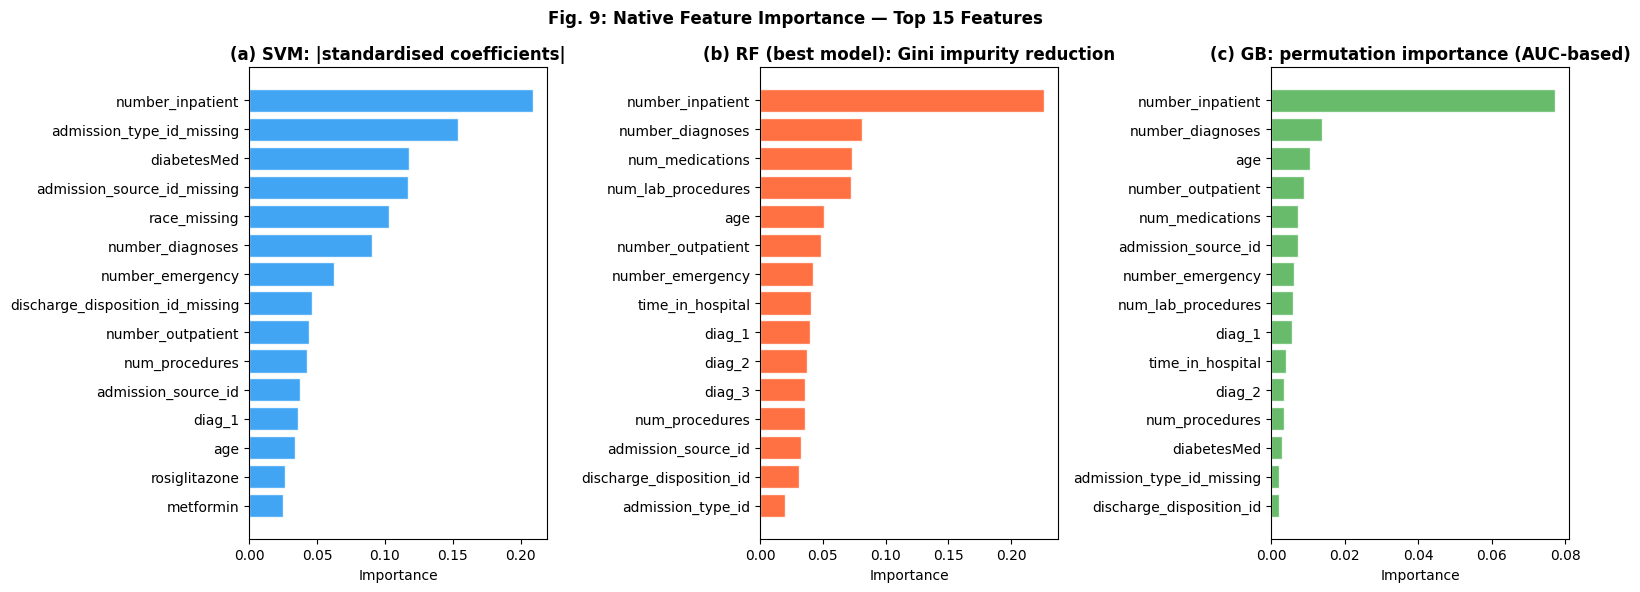


Top 15 SVM (|coef|):
  Rank  Feature                               Importance
  -------------------------------------------------------
  1     number_inpatient                          0.2090
  2     admission_type_id_missing                 0.1541
  3     diabetesMed                               0.1177
  4     admission_source_id_missing               0.1168
  5     race_missing                              0.1033
  6     number_diagnoses                          0.0905
  7     number_emergency                          0.0622
  8     discharge_disposition_id_missing          0.0464
  9     number_outpatient                         0.0443
  10    num_procedures                            0.0428
  11    admission_source_id                       0.0372
  12    diag_1                                    0.0361
  13    age                                       0.0335
  14    rosiglitazone                             0.0264
  15    metformin                                 0.0248

Top 15 

In [ ]:
from sklearn.inspection import permutation_importance

# extract importances
best_svm = gs_svm_full.best_estimator_
svm_coefs = np.abs(
    best_svm.named_steps['clf'].calibrated_classifiers_[0].estimator.coef_[0]
)

# RF: Gini
best_rf    = gs_rf_full.best_estimator_
rf_imp     = best_rf.named_steps['clf'].feature_importances_

# GB: permutation only — HistGradientBoostingClassifier has no feature_importances_
best_gb = gs_gb_full.best_estimator_
X_transformed_gb_full = best_gb.named_steps['pre'].transform(X)
perm_result = permutation_importance(
    best_gb.named_steps['clf'],
    X_transformed_gb_full, y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)
gb_imp = np.clip(perm_result.importances_mean, 0, None)

TOP_N = 15
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

def plot_importance(ax, importances, names, title, color, top_n=TOP_N):
    idx = np.argsort(importances)[-top_n:]
    ax.barh([names[i] for i in idx], importances[idx],
            color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')

plot_importance(axes[0], svm_coefs, all_feature_names,
                '(a) SVM: |standardised coefficients|', COLORS[0])
plot_importance(axes[1], rf_imp,    all_feature_names,
                '(b) RF (best model): Gini impurity reduction', COLORS[1])
plot_importance(axes[2], gb_imp,    all_feature_names,
                '(c) GB: permutation importance (AUC-based)', COLORS[2])

plt.suptitle('Fig. 9: Native Feature Importance — Top 15 Features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig09_native_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#numerical summaries
print('='*65)
for name, imp in [('SVM (|coef|)',          svm_coefs),
                   ('RF  (Gini)',             rf_imp),
                   ('GB  (permutation AUC)', gb_imp)]:
    idx = np.argsort(imp)[::-1]
    print(f'\nTop 15 {name}:')
    print(f'  {"Rank":<5} {"Feature":<35} {"Importance":>12}')
    print('  ' + '-'*55)
    for rank, i in enumerate(idx[:15], 1):
        print(f'  {rank:<5} {all_feature_names[i]:<35} {imp[i]:>12.4f}')

# analysing importance consensus
print('\n' + '='*65)
top10_svm = set(np.argsort(svm_coefs)[::-1][:10])
top10_rf  = set(np.argsort(rf_imp)[::-1][:10])
top10_gb  = set(np.argsort(gb_imp)[::-1][:10])

print('Consensus — in top 10 of ALL three models:')
for i in sorted(top10_svm & top10_rf & top10_gb):
    print(f'  {all_feature_names[i]}')

print('\nIn top 10 of RF and GB but not SVM:')
for i in sorted((top10_rf & top10_gb) - top10_svm):
    print(f'  {all_feature_names[i]}')

print('\nIn top 10 of SVM only (not RF or GB):')
for i in sorted(top10_svm - top10_rf - top10_gb):
    print(f'  {all_feature_names[i]}')

print('\nIn top 10 of RF only (not SVM or GB):')
for i in sorted(top10_rf - top10_svm - top10_gb):
    print(f'  {all_feature_names[i]}')

Computing SHAP:

In [ ]:
# transform X with the best preprocessors
X_transformed_rf  = best_rf.named_steps['pre'].transform(X)
X_transformed_svm = best_svm.named_steps['pre'].transform(X)

# RF SHAP TreeExplainer for best model
print('Computing SHAP values for RF (TreeExplainer)...')
explainer_rf   = shap.TreeExplainer(best_rf.named_steps['clf'])
shap_values_rf = explainer_rf.shap_values(X_transformed_rf)

# RF returns array of shape (n_samples, n_features, n_classes)
if isinstance(shap_values_rf, list):
    shap_vals_rf = shap_values_rf[1]
elif shap_values_rf.ndim == 3:
    shap_vals_rf = shap_values_rf[:, :, 1]
else:
    shap_vals_rf = shap_values_rf

# SVM SHAP LinearExplainer
print('Computing SHAP values for SVM (LinearExplainer)...')
svm_inner  = best_svm.named_steps['clf'].calibrated_classifiers_[0].estimator
background = shap.maskers.Independent(X_transformed_svm, max_samples=200)
explainer_svm   = shap.LinearExplainer(svm_inner, background)
shap_values_svm = explainer_svm.shap_values(X_transformed_svm)

# GB SHAP TreeExplainer
print('Computing SHAP values for GB (TreeExplainer)...')
X_transformed_gb_shap = best_gb.named_steps['pre'].transform(X.iloc[shap_idx] if 'shap_idx' in dir() else X)
explainer_gb   = shap.TreeExplainer(best_gb.named_steps['clf'])
shap_values_gb = explainer_gb.shap_values(X_transformed_gb_shap)

if isinstance(shap_values_gb, list):
    shap_vals_gb = shap_values_gb[1]
elif shap_values_gb.ndim == 3:
    shap_vals_gb = shap_values_gb[:, :, 1]
else:
    shap_vals_gb = shap_values_gb

print('SHAP values computed.')
print(f'RF SHAP shape:  {shap_vals_rf.shape}')
print(f'GB SHAP shape: {shap_vals_gb.shape}')
print(f'SVM SHAP shape: {shap_values_svm.shape}')

Computing SHAP values for RF (TreeExplainer)...
Computing SHAP values for SVM (LinearExplainer)...
Computing SHAP values for GB (TreeExplainer)...
SHAP values computed.
RF SHAP shape:  (20000, 36)
GB SHAP shape: (20000, 36)
SVM SHAP shape: (20000, 36)


Fig 13: SHAP beeswarm and dependence plots

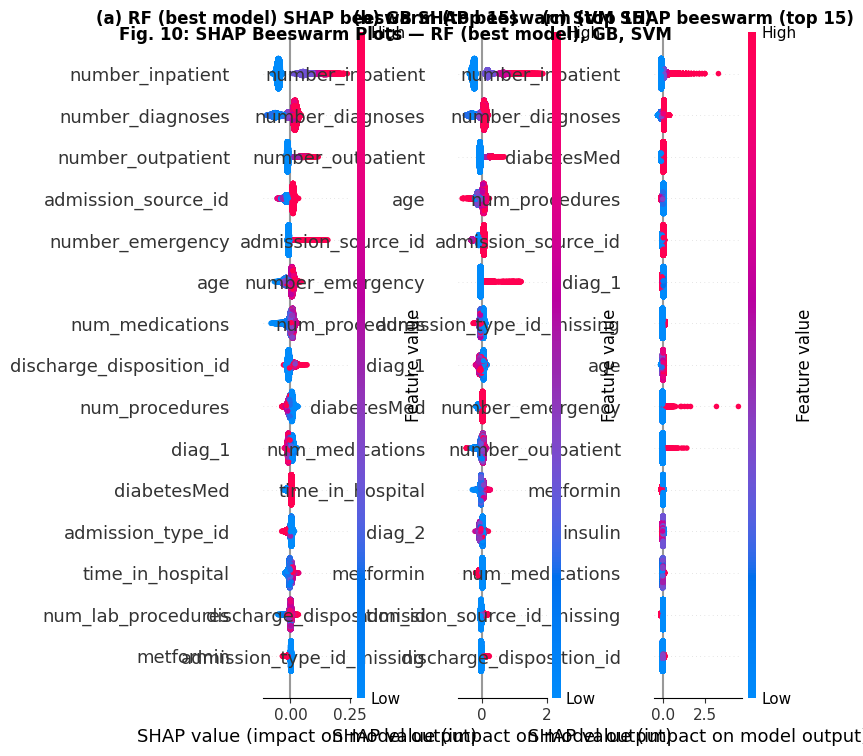


Top 15 RF  (best model) SHAP (mean |SHAP value|):
  Rank  Feature                              Mean |SHAP|
  -------------------------------------------------------
  1     number_inpatient                          0.0673
  2     number_diagnoses                          0.0280
  3     number_outpatient                         0.0192
  4     admission_source_id                       0.0147
  5     number_emergency                          0.0131
  6     age                                       0.0129
  7     num_medications                           0.0108
  8     discharge_disposition_id                  0.0100
  9     num_procedures                            0.0076
  10    diag_1                                    0.0073
  11    diabetesMed                               0.0059
  12    admission_type_id                         0.0057
  13    time_in_hospital                          0.0056
  14    num_lab_procedures                        0.0040
  15    metformin                   

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

plt.sca(axes[0])
shap.summary_plot(
    shap_vals_rf,
    X_transformed_rf,
    feature_names=all_feature_names,
    max_display=15,
    show=False,
    plot_type='dot'
)
axes[0].set_title('(a) RF (best model) SHAP beeswarm (top 15)', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(
    shap_vals_gb,
    X_transformed_gb_shap,
    feature_names=all_feature_names,
    max_display=15,
    show=False,
    plot_type='dot'
)
axes[1].set_title('(b) GB SHAP beeswarm (top 15)', fontweight='bold')

plt.sca(axes[2])
shap.summary_plot(
    shap_values_svm,
    X_transformed_svm,
    feature_names=all_feature_names,
    max_display=15,
    show=False,
    plot_type='dot'
)
axes[2].set_title('(c) SVM SHAP beeswarm (top 15)', fontweight='bold')

plt.suptitle('Fig. 10: SHAP Beeswarm Plots — RF (best model), GB, SVM',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig10a_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

mean_abs_shap_rf  = np.abs(shap_vals_rf).mean(axis=0)
mean_abs_shap_gb  = np.abs(shap_vals_gb).mean(axis=0)
mean_abs_shap_svm = np.abs(shap_values_svm).mean(axis=0)

for label, mean_shap in [('RF  (best model)', mean_abs_shap_rf),
                          ('GB',               mean_abs_shap_gb),
                          ('SVM',              mean_abs_shap_svm)]:
    idx = np.argsort(mean_shap)[::-1]
    print(f'\nTop 15 {label} SHAP (mean |SHAP value|):')
    print(f'  {"Rank":<5} {"Feature":<35} {"Mean |SHAP|":>12}')
    print('  ' + '-'*55)
    for rank, i in enumerate(idx[:15], 1):
        print(f'  {rank:<5} {all_feature_names[i]:<35} {mean_shap[i]:>12.4f}')

# comparing Gini vs SHAP for RF
print('\n' + '='*65)
print('RF: Gini rank vs SHAP rank — top 15 by SHAP:')
print(f'  {"SHAP Rnk":<10} {"Feature":<35} {"SHAP":>8} {"Gini Rnk":>10} {"Gini":>8}')
print('  ' + '-'*75)
idx_rf_shap  = np.argsort(mean_abs_shap_rf)[::-1]
idx_gb_shap  = np.argsort(mean_abs_shap_gb)[::-1]
idx_svm_shap = np.argsort(mean_abs_shap_svm)[::-1]
gini_ranks   = {i: rank for rank, i in enumerate(np.argsort(rf_imp)[::-1], 1)}
for rank, i in enumerate(idx_rf_shap[:15], 1):
    print(f'  {rank:<10} {all_feature_names[i]:<35} '
          f'{mean_abs_shap_rf[i]:>8.4f} {gini_ranks[i]:>10} {rf_imp[i]:>8.4f}')

# cross-model SHAP consensus
print('\n' + '='*65)
top10_shap_rf  = set(idx_rf_shap[:10])
top10_shap_gb  = set(idx_gb_shap[:10])
top10_shap_svm = set(idx_svm_shap[:10])

print('Consensus — in top 10 SHAP of ALL three models:')
for i in sorted(top10_shap_rf & top10_shap_gb & top10_shap_svm):
    print(f'  {all_feature_names[i]}')

print('\nIn top 10 SHAP of RF and GB only:')
for i in sorted((top10_shap_rf & top10_shap_gb) - top10_shap_svm):
    print(f'  {all_feature_names[i]}')

print('\nIn top 10 SHAP of SVM only:')
for i in sorted(top10_shap_svm - top10_shap_rf - top10_shap_gb):
    print(f'  {all_feature_names[i]}')

print('\nIn top 10 SHAP of RF only:')
for i in sorted(top10_shap_rf - top10_shap_gb - top10_shap_svm):
    print(f'  {all_feature_names[i]}')

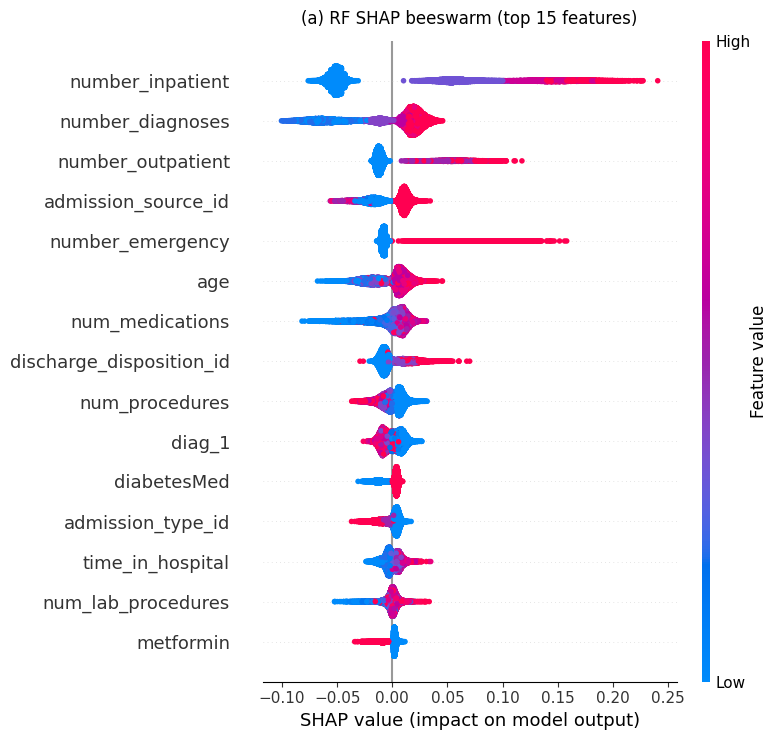

Saved: Fig10a_shap_rf.png


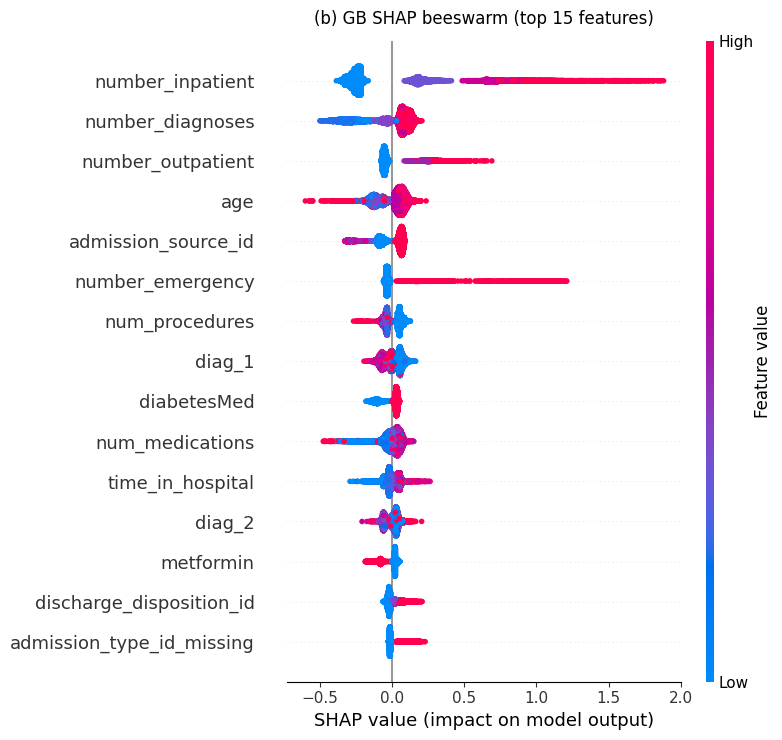

Saved: Fig10b_shap_gb.png


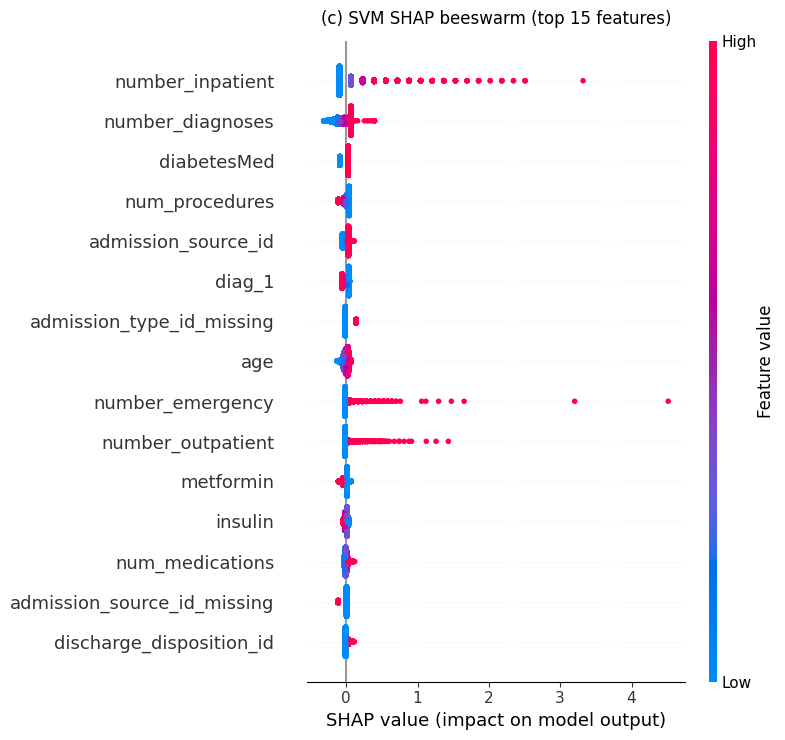

Saved: Fig10c_shap_svm.png


In [ ]:
# plotting beeswarms separately for clarity
for label, shap_vals, X_trans, fname in [
    ('(a) RF SHAP beeswarm (top 15 features)',
     shap_vals_rf,    X_transformed_rf,       'Fig10a_shap_rf.png'),
    ('(b) GB SHAP beeswarm (top 15 features)',
     shap_vals_gb,    X_transformed_gb_shap,  'Fig10b_shap_gb.png'),
    ('(c) SVM SHAP beeswarm (top 15 features)',
     shap_values_svm, X_transformed_svm,      'Fig10c_shap_svm.png'),
]:
    fig, ax = plt.subplots(figsize=(10, 7))
    plt.sca(ax)
    shap.summary_plot(
        shap_vals,
        X_trans,
        feature_names=all_feature_names,
        max_display=15,
        show=False,
        plot_type='dot'
    )
    ax.set_title(label, pad=12)
    plt.tight_layout()
    plt.savefig(FIGDIR + fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

Fig. 14: SHAP dependence plot for top RF feature

Top RF SHAP feature: number_inpatient


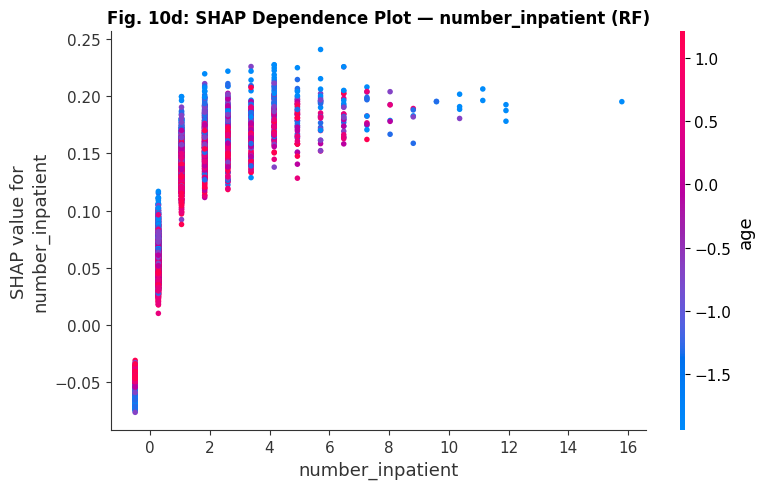


SHAP dependence — number_inpatient:
  Bin range                 N    Mean SHAP   Std SHAP
  ----------------------------------------------------
  [ -0.50,   0.28]     17100      -0.0269     0.0460
  [  0.28,  15.79]      6755       0.0986     0.0513

Monotonicity check:
  Pearson correlation (feature value vs SHAP): 0.8513
  Min SHAP: -0.0762
  Max SHAP: 0.2407
  Values where SHAP < 0: 66.2% of samples


In [ ]:
# Want to see how SHAP value for the top feature varies with its raw value
# colour encodes the automatically selected interaction feature (SHAP default)
# reveals whether the relationship is monotone, threshold-based, or non-linear
top_shap_idx  = np.argmax(mean_abs_shap_rf)
top_shap_name = all_feature_names[top_shap_idx]
print(f'Top RF SHAP feature: {top_shap_name}')

fig, ax = plt.subplots(figsize=(8, 5))
plt.sca(ax)
# shap.dependence_plot automatically selects the strongest interaction feature
# for colouring — provides richer interpretation than a simple scatter
shap.dependence_plot(
    top_shap_idx,
    shap_vals_rf,
    X_transformed_rf,
    feature_names=all_feature_names,
    ax=ax,
    show=False
)
ax.set_title(f'Fig. 10d: SHAP Dependence Plot — {top_shap_name} (RF)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig10d_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# numerical breakdown by percentile bin to identify threshold
print(f'\nSHAP dependence — {top_shap_name}:')
feat_vals  = X_transformed_rf[:, top_shap_idx]
shap_vals_feat = shap_vals_rf[:, top_shap_idx]


# percentile bins capture the skewed distribution of number_inpatient
# (median=0, long right tail) more faithfully than equal-width bins
bins = np.percentile(feat_vals, [0, 20, 40, 60, 80, 100])
bins = np.unique(bins)
print(f'  {"Bin range":<20} {"N":>6} {"Mean SHAP":>12} {"Std SHAP":>10}')
print('  ' + '-'*52)
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (feat_vals >= lo) & (feat_vals <= hi)
    if mask.sum() == 0:
        continue
    print(f'  [{lo:6.2f}, {hi:6.2f}]    {mask.sum():>6} '
          f'{shap_vals_feat[mask].mean():>12.4f} '
          f'{shap_vals_feat[mask].std():>10.4f}')

# monotonicity check — Pearson r quantifies how linearly the SHAP
# value tracks the feature; r < 1 confirms non-linear/threshold behaviour
print(f'\nMonotonicity check:')
print(f'  Pearson correlation (feature value vs SHAP): '
      f'{np.corrcoef(feat_vals, shap_vals_feat)[0,1]:.4f}')
print(f'  Min SHAP: {shap_vals_feat.min():.4f}')
print(f'  Max SHAP: {shap_vals_feat.max():.4f}')

# proportion with negative SHAP = zero prior inpatient visits
# reduces predicted readmission probability — cited directly in §4.1
print(f'  Values where SHAP < 0: {(shap_vals_feat < 0).mean()*100:.1f}% of samples')

Subgroup fairness audit:

In [ ]:
# this code evaluates equalised-odds parity across racial groups using the best RF model
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.base import clone

# collect predictions across all 5 outer folds with race labels
# pooling across folds maximises sample size per group for fairer estimates
# race preserved separately from X to avoid identity leakage
all_y_true = []
all_y_prob = []
all_race   = []

outer_splits = list(outer_cv.split(X, y, groups))

for fold, (tr_idx, te_idx) in enumerate(outer_splits):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y[tr_idx],      y[te_idx]

     # clone best RF to avoid fitting state leaking across folds
    rf_fold = clone(best_rf)
    rf_fold.fit(X_tr, y_tr)

    y_prob_fold = rf_fold.predict_proba(X_te)[:, 1]
    race_fold   = race_s.iloc[te_idx].values

    all_y_true.extend(y_te.tolist())
    all_y_prob.extend(y_prob_fold.tolist())
    all_race.extend(race_fold.tolist())
    print(f'  Fold {fold+1} done.')

all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)
all_race   = np.array(all_race)
all_y_pred = (all_y_prob >= 0.5).astype(int)

# overall pooled metrics used as reference baseline for disparity calculation
overall_auc = roc_auc_score(all_y_true, all_y_prob)
overall_tpr = all_y_pred[all_y_true==1].mean()
overall_fpr = all_y_pred[all_y_true==0].mean()

print(f'\nOverall (all groups pooled):')
print(f'  AUC={overall_auc:.4f}, TPR={overall_tpr:.4f}, FPR={overall_fpr:.4f}')

# per-group metrics — AUC, TPR (recall), FPR, Precision
# TPR and FPR parity are the equalised-odds criteria
# n<20 threshold excludes groups too small for reliable estimation
groups_fair = ['Caucasian', 'AfricanAmerican', 'Hispanic', 'Asian', 'Other']
fair_results = {}

print(f'\n{"Group":<20} {"N":>6} {"AUC":>8} {"TPR":>8} {"FPR":>8} {"Precision":>10}')
print('-'*60)
for grp in groups_fair:
    mask = all_race == grp
    if mask.sum() < 20:
        continue
    yt  = all_y_true[mask]
    yp  = all_y_pred[mask]
    ypr = all_y_prob[mask]
    # AUC requires both classes present — nan if group too homogeneous
    try:
        auc_g = roc_auc_score(yt, ypr)
    except:
        auc_g = float('nan')
    # derive TPR, FPR, Precision directly from confusion matrix
    # avoids sklearn metric edge cases for small groups
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
    tpr_g  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    fpr_g  = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
    prec_g = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    fair_results[grp] = {'n': mask.sum(), 'auc': auc_g,
                         'tpr': tpr_g, 'fpr': fpr_g, 'prec': prec_g}
    print(f'{grp:<20} {mask.sum():>6} {auc_g:>8.3f} {tpr_g:>8.3f} '
          f'{fpr_g:>8.3f} {prec_g:>10.3f}')

# disparity relative to overall pooled values
print('\nKey disparities vs overall:')
print(f'  {"Group":<20} {"ΔAUC":>8} {"ΔTPR":>8} {"ΔFPR":>8}')
print('  ' + '-'*48)
for grp, res in fair_results.items():
    print(f'  {grp:<20} '
          f'{res["auc"]-overall_auc:>+8.3f} '
          f'{res["tpr"]-overall_tpr:>+8.3f} '
          f'{res["fpr"]-overall_fpr:>+8.3f}')

# direct comparison of two largest groups
if 'Caucasian' in fair_results and 'AfricanAmerican' in fair_results:
    print(f'\nAfricanAmerican vs Caucasian:')
    print(f'  ΔAUC = {fair_results["AfricanAmerican"]["auc"]-fair_results["Caucasian"]["auc"]:+.4f}')
    print(f'  ΔTPR = {fair_results["AfricanAmerican"]["tpr"]-fair_results["Caucasian"]["tpr"]:+.4f}')
    print(f'  ΔFPR = {fair_results["AfricanAmerican"]["fpr"]-fair_results["Caucasian"]["fpr"]:+.4f}')

  Fold 1 done.
  Fold 2 done.
  Fold 3 done.
  Fold 4 done.
  Fold 5 done.

Overall (all groups pooled):
  AUC=0.6757, TPR=0.5584, FPR=0.3104

Group                     N      AUC      TPR      FPR  Precision
------------------------------------------------------------
Caucasian             15010    0.671    0.566    0.326      0.616
AfricanAmerican        3726    0.683    0.561    0.294      0.629
Hispanic                400    0.692    0.524    0.246      0.597
Asian                   120    0.663    0.385    0.296      0.385
Other                   295    0.671    0.394    0.210      0.524

Key disparities vs overall:
  Group                    ΔAUC     ΔTPR     ΔFPR
  ------------------------------------------------
  Caucasian              -0.005   +0.008   +0.015
  AfricanAmerican        +0.007   +0.003   -0.016
  Hispanic               +0.016   -0.034   -0.065
  Asian                  -0.013   -0.174   -0.014
  Other                  -0.005   -0.164   -0.101

AfricanAmerican vs 

Fig. 15: Fairness audit plot

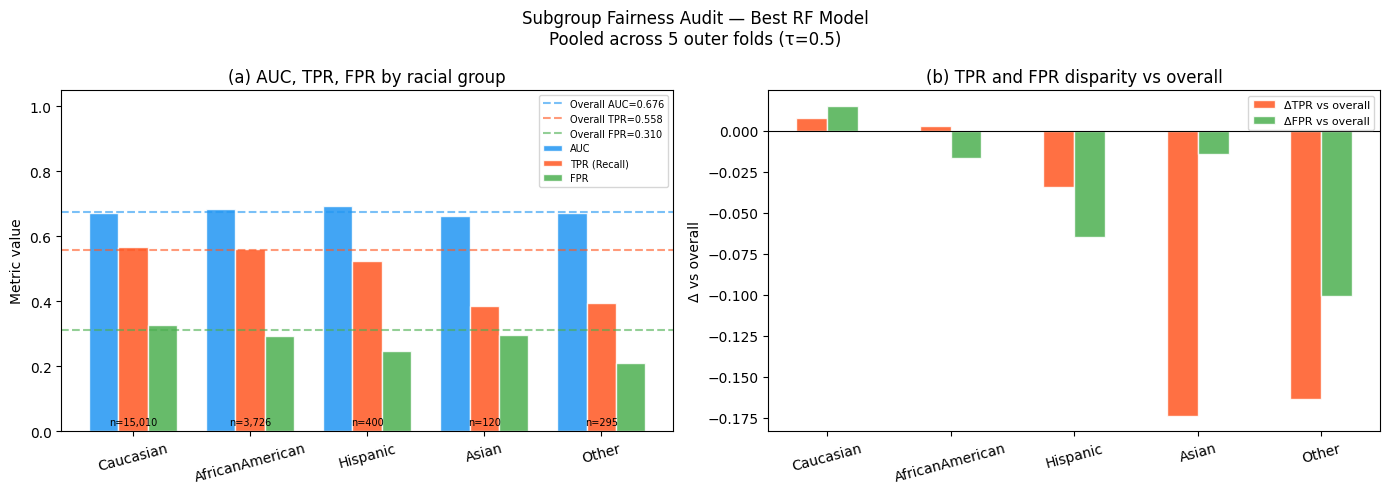

Fig 14: Fairness Audit — Numerical Summary
Overall: AUC=0.6757, TPR=0.5584, FPR=0.3104

Group                     N      AUC      TPR      FPR     ΔAUC     ΔTPR     ΔFPR
---------------------------------------------------------------------------
Caucasian             15010    0.671    0.566    0.326   -0.005   +0.008   +0.015
AfricanAmerican        3726    0.683    0.561    0.294   +0.007   +0.003   -0.016
Hispanic                400    0.692    0.524    0.246   +0.016   -0.034   -0.065
Asian                   120    0.663    0.385    0.296   -0.013   -0.174   -0.014
Other                   295    0.671    0.394    0.210   -0.005   -0.164   -0.101

Equalised odds assessment (TPR and FPR parity):
  Caucasian            TPR parity: ✓            FPR parity: ✓
  AfricanAmerican      TPR parity: ✓            FPR parity: ✓
  Hispanic             TPR parity: ✓            FPR parity: ✗ VIOLATED
  Asian                TPR parity: ✗ VIOLATED   FPR parity: ✓
  Other                TPR parity: ✗ V

In [ ]:
grp_names = [g for g in groups_fair if g in fair_results]
auc_vals  = [fair_results[g]['auc'] for g in grp_names]
tpr_vals  = [fair_results[g]['tpr'] for g in grp_names]
fpr_vals  = [fair_results[g]['fpr'] for g in grp_names]
n_vals    = [fair_results[g]['n']   for g in grp_names]

x     = np.arange(len(grp_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AUC, TPR, FPR bars
ax = axes[0]
ax.bar(x - width, auc_vals, width, label='AUC',
       color=COLORS[0], edgecolor='white', alpha=0.85)
ax.bar(x,          tpr_vals, width, label='TPR (Recall)',
       color=COLORS[1], edgecolor='white', alpha=0.85)
ax.bar(x + width,  fpr_vals, width, label='FPR',
       color=COLORS[2], edgecolor='white', alpha=0.85)

ax.axhline(overall_auc, color=COLORS[0], linestyle='--', alpha=0.6,
           label=f'Overall AUC={overall_auc:.3f}')
ax.axhline(overall_tpr, color=COLORS[1], linestyle='--', alpha=0.6,
           label=f'Overall TPR={overall_tpr:.3f}')
ax.axhline(overall_fpr, color=COLORS[2], linestyle='--', alpha=0.6,
           label=f'Overall FPR={overall_fpr:.3f}')

# Annotate N
for i, (xi, n) in enumerate(zip(x, n_vals)):
    ax.text(xi, 0.02, f'n={n:,}', ha='center', fontsize=7, color='black')

ax.set_xticks(x)
ax.set_xticklabels(grp_names, rotation=15)
ax.set_ylabel('Metric value')
ax.set_ylim(0, 1.05)
ax.set_title('(a) AUC, TPR, FPR by racial group')
ax.legend(fontsize=7, loc='upper right')

# Right: ΔTPR and ΔFPR vs overall
delta_tpr = [fair_results[g]['tpr'] - overall_tpr for g in grp_names]
delta_fpr = [fair_results[g]['fpr'] - overall_fpr for g in grp_names]

ax2 = axes[1]
ax2.bar(x - width/2, delta_tpr, width, label='ΔTPR vs overall',
        color=COLORS[1], edgecolor='white', alpha=0.85)
ax2.bar(x + width/2, delta_fpr, width, label='ΔFPR vs overall',
        color=COLORS[2], edgecolor='white', alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(grp_names, rotation=15)
ax2.set_ylabel('Δ vs overall')
ax2.set_title('(b) TPR and FPR disparity vs overall')
ax2.legend(fontsize=8)

plt.suptitle('Subgroup Fairness Audit — Best RF Model\n'
             'Pooled across 5 outer folds (τ=0.5)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig14_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()

print('='*65)
print('Fig 14: Fairness Audit — Numerical Summary')
print(f'Overall: AUC={overall_auc:.4f}, TPR={overall_tpr:.4f}, FPR={overall_fpr:.4f}')
print()
print(f'{"Group":<20} {"N":>6} {"AUC":>8} {"TPR":>8} {"FPR":>8} {"ΔAUC":>8} {"ΔTPR":>8} {"ΔFPR":>8}')
print('-'*75)
for grp in grp_names:
    r = fair_results[grp]
    print(f'{grp:<20} {r["n"]:>6} {r["auc"]:>8.3f} {r["tpr"]:>8.3f} {r["fpr"]:>8.3f} '
          f'{r["auc"]-overall_auc:>+8.3f} {r["tpr"]-overall_tpr:>+8.3f} {r["fpr"]-overall_fpr:>+8.3f}')

print()
print('Equalised odds assessment (TPR and FPR parity):')
for grp in grp_names:
    r = fair_results[grp]
    tpr_ok = abs(r['tpr'] - overall_tpr) < 0.05
    fpr_ok = abs(r['fpr'] - overall_fpr) < 0.05
    print(f'  {grp:<20} TPR parity: {"✓" if tpr_ok else "✗ VIOLATED":<12} '
          f'FPR parity: {"✓" if fpr_ok else "✗ VIOLATED"}')

print()
print('AfricanAmerican vs Caucasian (two largest groups):')
print(f'  ΔAUC = {fair_results["AfricanAmerican"]["auc"]-fair_results["Caucasian"]["auc"]:+.4f}')
print(f'  ΔTPR = {fair_results["AfricanAmerican"]["tpr"]-fair_results["Caucasian"]["tpr"]:+.4f}')
print(f'  ΔFPR = {fair_results["AfricanAmerican"]["fpr"]-fair_results["Caucasian"]["fpr"]:+.4f}')

## Task 5 — Alternative ML Pipeline

### 5.1 and 5.2 Best Model, Feature Selection, and CV performance table

Strategy A: feature selection using RF Gini importance as the selection criterion. A first RF fits on the training data to learn feature importances; features above a threshold τ are retained; a second RF trains on the reduced feature set for prediction.

In [ ]:
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.base import clone

def make_strategy_a_pipeline(threshold='median'):
    """Builds Strategy A pipeline: SelectFromModel(RF) + RF classifier.
    Selector and classifier use separate RF instances — selector learns
    feature importances, classifier learns the prediction task.
    threshold tuned as a hyperparameter in inner CV to prevent
    selection-bias leakage"""
    selector = SelectFromModel(
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
        threshold=threshold,
        prefit=False # selector fitted within pipeline, not pre-fitted
    )
    clf = RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    return Pipeline([
        ('pre',      preprocessor),
        ('selector', selector),
        ('clf',      clf)
    ])


# threshold included in grid alongside RF hyperparameters so that
# threshold selection cannot observe test data — prevents optimistic bias
param_grid_a = {
    'selector__threshold':   ['median', 'mean', '1.25*mean'],
    'clf__n_estimators':     [100, 200],
    'clf__max_depth':        [5, 10],
    'clf__min_samples_leaf': [1, 5],
    'clf__max_features':     ['sqrt', 'log2']
}
# 3 x 2 x 2 x 2 x 2 = 48 candidates
print('Strategy A pipeline defined (SelectFromModel + RF).')
print('Grid size:', 3 * 2 * 2 * 2 * 2, 'candidates')

Strategy A pipeline defined (SelectFromModel + RF).
Grid size: 48 candidates


For first part of Table 2 in text (Strategy A performance):

In [ ]:
# Same nested StratifiedGroupKFold structure as Task 3
# patient-level grouping maintained throughout to prevent leakage
inner_cv_5 = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv_5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

fold_test_metrics_a = []
fold_val_metrics_a  = []
fold_features_a     = [] # feature indices selected per fold — needed for Jaccard stability
fold_n_features_a   = [] # feature count per fold

print('Running Strategy A nested CV (SelectFromModel + RF)...')
for fold, (tr_idx, te_idx) in enumerate(outer_cv_5.split(X, y, groups)):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y[tr_idx],      y[te_idx]
    g_tr       = groups[tr_idx]

    # fresh pipeline per fold — selector and classifier refitted independently
    # within each outer fold to prevent feature selection statistics leaking
    pipe_a = make_strategy_a_pipeline()
    gs_a = GridSearchCV(pipe_a, param_grid_a, cv=inner_cv_5,
                        scoring='roc_auc', n_jobs=-1, refit=True)
    gs_a.fit(X_tr, y_tr, groups=g_tr)

    # val metrics: refit best estimator on each inner fold independently
    # provides unbiased val estimate consistent with Task 3 reporting
    inner_fold_metrics_a = []
    for in_tr, in_val in inner_cv_5.split(X_tr, y_tr, g_tr):
        est_a = clone(gs_a.best_estimator_)
        est_a.fit(X_tr.iloc[in_tr], y_tr[in_tr])
        y_val_prob = est_a.predict_proba(X_tr.iloc[in_val])[:, 1]
        y_val_pred = est_a.predict(X_tr.iloc[in_val])
        inner_fold_metrics_a.append(
            compute_metrics(y_tr[in_val], y_val_prob, y_val_pred))
        # average val metrics across inner folds - need for table
    val_avg_a = {k: np.mean([m[k] for m in inner_fold_metrics_a])
                 for k in inner_fold_metrics_a[0].keys()}
    fold_val_metrics_a.append(val_avg_a)

    # feature mask — boolean array over post-preprocessing features
    # stored per fold to compute Jaccard stability across folds
    mask = gs_a.best_estimator_.named_steps['selector'].get_support()
    fold_features_a.append(np.where(mask)[0].tolist())
    fold_n_features_a.append(mask.sum())

    # outer test metrics — unbiased performance estimate on held-out fold
    y_prob = gs_a.predict_proba(X_te)[:, 1]
    y_pred = gs_a.predict(X_te)
    metrics = compute_metrics(y_te, y_prob, y_pred)
    fold_test_metrics_a.append(metrics)

    print(f'  Fold {fold+1}: '
          f'val_AUC={val_avg_a["auc"]:.4f} | '
          f'test_AUC={metrics["auc"]:.4f} | '
          f'recall={metrics["recall"]:.4f} | '
          f'n_features={mask.sum()} | '
          f'threshold={gs_a.best_params_["selector__threshold"]} | '
          f'best_params={gs_a.best_params_}')

# aggregate mean ± SD across 5 outer folds for table 2
metric_keys = list(fold_test_metrics_a[0].keys())
results_a = {}
for k in metric_keys:
    test_vals = [m[k] for m in fold_test_metrics_a]
    val_vals  = [m[k] for m in fold_val_metrics_a]
    results_a[k] = {
        'mean': np.mean(test_vals), 'std': np.std(test_vals), 'vals': test_vals}
    results_a[f'val_{k}'] = {
        'mean': np.mean(val_vals), 'std': np.std(val_vals), 'vals': val_vals}
      # feature count stability across folds — near-zero SD confirms robust selection
results_a['n_features'] = {
    'mean': np.mean(fold_n_features_a),
    'std':  np.std(fold_n_features_a),
    'vals': fold_n_features_a}

print(f'\nStrategy A summary:')
print(f'{"Metric":<12} {"Val mean±SD":>16} {"Test mean±SD":>16}')
print('-'*45)
for k in metric_keys:
    print(f'{k:<12} '
          f'{results_a[f"val_{k}"]["mean"]:>8.4f}±{results_a[f"val_{k}"]["std"]:.4f} '
          f'{results_a[k]["mean"]:>8.4f}±{results_a[k]["std"]:.4f}')
print(f'N features:  {results_a["n_features"]["mean"]:.1f} ± '
      f'{results_a["n_features"]["std"]:.1f}')
print(f'Per fold:    {fold_n_features_a}')
# save results for Jaccard analysis and Table 2 construction
with open(SAVE_DIR + 'results_a.pkl', 'wb') as f:
    pickle.dump({'results': results_a, 'features': fold_features_a,
                 'n_features': fold_n_features_a}, f)
print('Strategy A saved.')

Running Strategy A nested CV (SelectFromModel + RF)...
  Fold 1: val_AUC=0.6659 | test_AUC=0.6908 | recall=0.5795 | n_features=18 | threshold=median | best_params={'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200, 'selector__threshold': 'median'}
  Fold 2: val_AUC=0.6737 | test_AUC=0.6729 | recall=0.5497 | n_features=18 | threshold=median | best_params={'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200, 'selector__threshold': 'median'}
  Fold 3: val_AUC=0.6732 | test_AUC=0.6676 | recall=0.5443 | n_features=18 | threshold=median | best_params={'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200, 'selector__threshold': 'median'}
  Fold 4: val_AUC=0.6739 | test_AUC=0.6648 | recall=0.5519 | n_features=18 | threshold=median | best_params={'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimato

Calculating Strategy A jaccard stability:

In [ ]:
# get feature names after preprocessing — names needed to interpret
# feature indices stored in fold_features_a and fold_features_b
all_feature_names = preprocessor.get_feature_names_out()
# ColumnTransformer prefixes step names onto feature names (e.g. 'num__time_in_hospital')
# strip prefix to recover original feature names for readability
all_feature_names = [name.split('__')[-1] for name in all_feature_names]
print(f'Total features after preprocessing: {len(all_feature_names)}')
print('First 10:', all_feature_names[:10])

def jaccard(set_a, set_b):
    """
    Pairwise Jaccard similarity between two feature sets.
    |A ∩ B| / |A ∪ B| — 1.0 if identical, 0.0 if disjoint.
    Used to quantify selection stability across CV folds.
    """
    a, b = set(set_a), set(set_b)
    if len(a | b) == 0:
        return 1.0
    return len(a & b) / len(a | b)

def mean_pairwise_jaccard(feature_sets):
    """
    Mean pairwise Jaccard across all fold combinations (n=10 pairs for k=5).
    Returns mean and SD — high SD indicates fold-dependent instability.
    """
    n = len(feature_sets)
    scores = []
    for i in range(n):
        for j in range(i+1, n):
            scores.append(jaccard(feature_sets[i], feature_sets[j]))
    return np.mean(scores), np.std(scores)

# within-strategy stability — measures whether the same features are selected
# across different data splits
jac_a_mean, jac_a_std = mean_pairwise_jaccard(fold_features_a)
print(f'Strategy A Jaccard stability: {jac_a_mean:.3f} ± {jac_a_std:.3f}')
print('(>0.7 = stable, deployment-confident selection)')

# frequency table — features selected in all 5 folds form the stable model-agnostic core set
from collections import Counter
all_selected_a = [f for fold in fold_features_a for f in fold]
freq_a = Counter(all_selected_a)

print('\nFeatures selected in all 5 folds (Strategy A):')
print(f'  {"Feature":<35} {"Count":>6} {"Freq":>8}')
print('  ' + '-'*52)
for feat_idx, count in freq_a.most_common():
    print(f'  {all_feature_names[feat_idx]:<35} {count:>6} {count/5:>8.1f}')

# total unique features quantifies selection breadth vs stability trade-off
print(f'\nTotal unique features ever selected: {len(freq_a)}')
print(f'Features selected in all 5 folds:   {sum(1 for c in freq_a.values() if c==5)}')

Total features after preprocessing: 36
First 10: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age', 'race']
Strategy A Jaccard stability: 0.937 ± 0.052
(>0.7 = stable, deployment-confident selection)

Features selected in all 5 folds (Strategy A):
  Feature                              Count     Freq
  ----------------------------------------------------
  time_in_hospital                         5      1.0
  num_lab_procedures                       5      1.0
  num_procedures                           5      1.0
  num_medications                          5      1.0
  number_outpatient                        5      1.0
  number_inpatient                         5      1.0
  number_diagnoses                         5      1.0
  age                                      5      1.0
  race                                     5      1.0
  diag_1                                

Strategy B — RFECV (LinearSVC): feature selection using recursive feature elimination with cross-validation, where LinearSVC coefficient magnitudes determine which feature to eliminate at each step. The same model family (LinearSVC) is then refitted on the reduced feature set with Platt scaling for probability calibration.

In [ ]:
# RFECV + LinearSVC: wrapper method using linear discriminability
# as selection criterion — different from Strategy A's Gini importance
# NB limitation: StratifiedKFold used (not StratifiedGroupKFold) as RFECV
from sklearn.model_selection import StratifiedKFold

fold_test_metrics_b = []
fold_val_metrics_b  = []
fold_features_b     = [] # feature indices per fold — again used for Jaccard stability
fold_n_features_b   = []

print('Running Strategy B nested CV (RFECV + LinearSVC)...')
for fold, (tr_idx, te_idx) in enumerate(outer_cv_5.split(X, y, groups)):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y[tr_idx],      y[te_idx]

    # preprocessor cloned and fitted on training partition only —
    # Strategy B cannot use a Pipeline object because RFECV operates
    # on arrays, so leakage prevention is handled manually here
    pre_b    = clone(preprocessor)
    X_tr_pre = pre_b.fit_transform(X_tr, y_tr)
    X_te_pre = pre_b.transform(X_te)

    # RFECV eliminates one feature per step, selecting the subset that
    # maximises CV AUC — wrapper method ties selection directly to performance
    # C=0.01 matches best SVM from Task 3 nested C
    # NB min_features_to_select=5 used to prevent degenerate single-feature solutions
    svm_b = LinearSVC(class_weight='balanced', max_iter=5000,
                      random_state=42, C=0.01)
    rfecv = RFECV(
        estimator=svm_b,
        step=1,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1,
        min_features_to_select=5
    )
    rfecv.fit(X_tr_pre, y_tr)

    # boolean mask over post-preprocessing features — stored for Jaccard analysis
    mask_b = rfecv.get_support()
    fold_features_b.append(np.where(mask_b)[0].tolist())
    fold_n_features_b.append(mask_b.sum())

    # val metrics: refit calibrated SVM on each inner fold using selected features
    # Platt scaling (sigmoid) applied as LinearSVC has no native predict_proba
    inner_fold_metrics_b = []
    inner_cv_b = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    for in_tr, in_val in inner_cv_b.split(X_tr_pre, y_tr):
        svm_val = CalibratedClassifierCV(
            LinearSVC(class_weight='balanced', max_iter=5000,
                      random_state=42, C=0.01),
            method='sigmoid', cv=3)
        svm_val.fit(X_tr_pre[in_tr][:, mask_b], y_tr[in_tr])
        y_val_prob = svm_val.predict_proba(X_tr_pre[in_val][:, mask_b])[:, 1]
        y_val_pred = svm_val.predict(X_tr_pre[in_val][:, mask_b])
        inner_fold_metrics_b.append(
            compute_metrics(y_tr[in_val], y_val_prob, y_val_pred))
    # average val metrics across inner folds - again for table
    val_avg_b = {k: np.mean([m[k] for m in inner_fold_metrics_b])
                 for k in inner_fold_metrics_b[0].keys()}
    fold_val_metrics_b.append(val_avg_b)

    # refit final calibrated SVM on full training partition with selected features
    # separate from RFECV estimator — RFECV's internal SVM is uncalibrated
    svm_cal_b = CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=5000,
                  random_state=42, C=0.01),
        method='sigmoid', cv=3)
    svm_cal_b.fit(X_tr_pre[:, mask_b], y_tr)

    # outer test metrics — unbiased performance on held-out fold
    y_prob = svm_cal_b.predict_proba(X_te_pre[:, mask_b])[:, 1]
    y_pred = svm_cal_b.predict(X_te_pre[:, mask_b])
    metrics = compute_metrics(y_te, y_prob, y_pred)
    fold_test_metrics_b.append(metrics)

    print(f'  Fold {fold+1}: '
          f'val_AUC={val_avg_b["auc"]:.4f} | '
          f'test_AUC={metrics["auc"]:.4f} | '
          f'recall={metrics["recall"]:.4f} | '
          f'n_features={mask_b.sum()}')

# aggregate mean +- SD across 5 outer folds for table
metric_keys = list(fold_test_metrics_b[0].keys())
results_b = {}
for k in metric_keys:
    test_vals = [m[k] for m in fold_test_metrics_b]
    val_vals  = [m[k] for m in fold_val_metrics_b]
    results_b[k] = {
        'mean': np.mean(test_vals), 'std': np.std(test_vals), 'vals': test_vals}
    results_b[f'val_{k}'] = {
        'mean': np.mean(val_vals), 'std': np.std(val_vals), 'vals': val_vals}
# feature count stability
results_b['n_features'] = {
    'mean': np.mean(fold_n_features_b),
    'std':  np.std(fold_n_features_b),
    'vals': fold_n_features_b}

print(f'\nStrategy B summary:')
print(f'{"Metric":<12} {"Val mean±SD":>16} {"Test mean±SD":>16}')
print('-'*45)
for k in metric_keys:
    print(f'{k:<12} '
          f'{results_b[f"val_{k}"]["mean"]:>8.4f}±{results_b[f"val_{k}"]["std"]:.4f} '
          f'{results_b[k]["mean"]:>8.4f}±{results_b[k]["std"]:.4f}')
print(f'N features:  {results_b["n_features"]["mean"]:.1f} ± '
      f'{results_b["n_features"]["std"]:.1f}')
print(f'Per fold:    {fold_n_features_b}')

# save for Jaccard analysis
with open(SAVE_DIR + 'results_b.pkl', 'wb') as f:
    pickle.dump({'results': results_b, 'features': fold_features_b,
                 'n_features': fold_n_features_b}, f)
print('Strategy B saved.')

Running Strategy B nested CV (RFECV + LinearSVC)...
  Fold 1: val_AUC=0.6541 | test_AUC=0.6721 | recall=0.4747 | n_features=15
  Fold 2: val_AUC=0.6595 | test_AUC=0.6546 | recall=0.4567 | n_features=17
  Fold 3: val_AUC=0.6609 | test_AUC=0.6469 | recall=0.4536 | n_features=25
  Fold 4: val_AUC=0.6623 | test_AUC=0.6525 | recall=0.4573 | n_features=21
  Fold 5: val_AUC=0.6580 | test_AUC=0.6639 | recall=0.4633 | n_features=19

Strategy B summary:
Metric            Val mean±SD     Test mean±SD
---------------------------------------------
auc            0.6589±0.0028   0.6580±0.0089
pr_auc         0.6340±0.0049   0.6325±0.0160
recall         0.4583±0.0134   0.4611±0.0075
precision      0.6244±0.0018   0.6254±0.0201
f1             0.5284±0.0095   0.5308±0.0121
bal_acc        0.6062±0.0026   0.6076±0.0076
brier          0.2294±0.0005   0.2295±0.0012
N features:  19.4 ± 3.4
Per fold:    [np.int64(15), np.int64(17), np.int64(25), np.int64(21), np.int64(19)]
Strategy B saved.


Strategy B Jaccard analysis:

In [ ]:
# within-strategy stability for Strategy B
jac_b_mean, jac_b_std = mean_pairwise_jaccard(fold_features_b)
print(f'Strategy B Jaccard stability: {jac_b_mean:.3f} ± {jac_b_std:.3f}')

# frequency table — count=5 features form the stable Strategy B core
all_selected_b = [f for fold in fold_features_b for f in fold]
freq_b = Counter(all_selected_b)

print('\nFeatures by selection frequency (Strategy B):')
print(f'  {"Feature":<35} {"Count":>6} {"Freq":>8}')
print('  ' + '-'*52)
for feat_idx, count in freq_b.most_common():
    print(f'  {all_feature_names[feat_idx]:<35} {count:>6} {count/5:>8.1f}')

print(f'\nTotal unique features ever selected: {len(freq_b)}')
print(f'Features selected in all 5 folds:   {sum(1 for c in freq_b.values() if c==5)}')

# cross-strategy Jaccard — agreement between Gini-based (A) and linear discriminability-based (B) criteria; computed per fold
cross_jac = [jaccard(fold_features_a[i], fold_features_b[i]) for i in range(5)]
print(f'\nCross-strategy Jaccard (A vs B) per fold:')
for i, j in enumerate(cross_jac):
    print(f'  Fold {i+1}: {j:.3f}')
print(f'Mean: {np.mean(cross_jac):.3f} ± {np.std(cross_jac):.3f}')

# model-agnostic core — features stable in all 5 folds of both strategies
# these features satisfy both Gini importance and linear discriminability
top_a = set(i for i, c in freq_a.items() if c == 5)
top_b = set(i for i, c in freq_b.items() if c == 5)
print(f'\nFeatures stable in BOTH strategies (selected in all 5 folds of A and B):')
for i in sorted(top_a & top_b):
    print(f'  {all_feature_names[i]}')

# printing strategy-exclusive features
print(f'\nStable in A only (not all 5 folds of B):')
for i in sorted(top_a - top_b):
    print(f'  {all_feature_names[i]}')

print(f'\nStable in B only (not all 5 folds of A):')
for i in sorted(top_b - top_a):
    print(f'  {all_feature_names[i]}')

Strategy B Jaccard stability: 0.752 ± 0.065

Features by selection frequency (Strategy B):
  Feature                              Count     Freq
  ----------------------------------------------------
  num_procedures                           5      1.0
  number_outpatient                        5      1.0
  number_emergency                         5      1.0
  number_inpatient                         5      1.0
  number_diagnoses                         5      1.0
  age                                      5      1.0
  diag_1                                   5      1.0
  metformin                                5      1.0
  admission_source_id                      5      1.0
  diabetesMed                              5      1.0
  race_missing                             5      1.0
  admission_type_id_missing                5      1.0
  discharge_disposition_id_missing         5      1.0
  admission_source_id_missing              5      1.0
  time_in_hospital                         4

### 5.2 Full performance comparison table

In [ ]:
print("Full performance comparison")
print(f'{"Pipeline":<24} {"AUC":>12} {"PR-AUC":>12} {"Recall":>10} '
      f'{"Precision":>10} {"F1":>10} {"Feats":>8} {"Jaccard":>10}')
print('-'*95)

# Reference baselines from Task 3
rf_auc  = results_rf['auc']['mean']
rf_std  = results_rf['auc']['std']
svm_auc = results_svm['auc']['mean']
svm_std = results_svm['auc']['std']

print(f'{"RF full (36 feats)":<24} '
      f'{rf_auc:>6.3f}±{rf_std:.3f} '
      f'{results_rf["pr_auc"]["mean"]:>6.3f}±{results_rf["pr_auc"]["std"]:.3f} '
      f'{results_rf["recall"]["mean"]:>6.3f}±{results_rf["recall"]["std"]:.3f} '
      f'{results_rf["precision"]["mean"]:>6.3f}±{results_rf["precision"]["std"]:.3f} '
      f'{results_rf["f1"]["mean"]:>6.3f}±{results_rf["f1"]["std"]:.3f} '
      f'{"36":>8} {"---":>10}')

print(f'{"SVM full (36 feats)":<24} '
      f'{svm_auc:>6.3f}±{svm_std:.3f} '
      f'{results_svm["pr_auc"]["mean"]:>6.3f}±{results_svm["pr_auc"]["std"]:.3f} '
      f'{results_svm["recall"]["mean"]:>6.3f}±{results_svm["recall"]["std"]:.3f} '
      f'{results_svm["precision"]["mean"]:>6.3f}±{results_svm["precision"]["std"]:.3f} '
      f'{results_svm["f1"]["mean"]:>6.3f}±{results_svm["f1"]["std"]:.3f} '
      f'{"36":>8} {"---":>10}')

print(f'{"Strategy A (SFM+RF)":<24} '
      f'{results_a["auc"]["mean"]:>6.3f}±{results_a["auc"]["std"]:.3f} '
      f'{results_a["pr_auc"]["mean"]:>6.3f}±{results_a["pr_auc"]["std"]:.3f} '
      f'{results_a["recall"]["mean"]:>6.3f}±{results_a["recall"]["std"]:.3f} '
      f'{results_a["precision"]["mean"]:>6.3f}±{results_a["precision"]["std"]:.3f} '
      f'{results_a["f1"]["mean"]:>6.3f}±{results_a["f1"]["std"]:.3f} '
      f'{results_a["n_features"]["mean"]:>6.1f}±{results_a["n_features"]["std"]:.1f} '
      f'{jac_a_mean:>6.3f}±{jac_a_std:.3f}')

print(f'{"Strategy B (RFECV+SVM)":<24} '
      f'{results_b["auc"]["mean"]:>6.3f}±{results_b["auc"]["std"]:.3f} '
      f'{results_b["pr_auc"]["mean"]:>6.3f}±{results_b["pr_auc"]["std"]:.3f} '
      f'{results_b["recall"]["mean"]:>6.3f}±{results_b["recall"]["std"]:.3f} '
      f'{results_b["precision"]["mean"]:>6.3f}±{results_b["precision"]["std"]:.3f} '
      f'{results_b["f1"]["mean"]:>6.3f}±{results_b["f1"]["std"]:.3f} '
      f'{results_b["n_features"]["mean"]:>6.1f}±{results_b["n_features"]["std"]:.1f} '
      f'{jac_b_mean:>6.3f}±{jac_b_std:.3f}')

print()
delta_a = results_a['auc']['mean'] - rf_auc
delta_b = results_b['auc']['mean'] - svm_auc
print(f'ΔAUC Strategy A vs RF full:  {delta_a:+.4f}')
print(f'ΔAUC Strategy B vs SVM full: {delta_b:+.4f}')
print(f'Cross-strategy Jaccard (A vs B): {np.mean(cross_jac):.3f} ± {np.std(cross_jac):.3f}')
print(f'Model-agnostic robust core (stable in both): 7 features')

Full performance comparison
Pipeline                          AUC       PR-AUC     Recall  Precision         F1    Feats    Jaccard
-----------------------------------------------------------------------------------------------
RF full (36 feats)        0.677±0.011  0.647±0.017  0.564±0.012  0.615±0.018  0.588±0.015       36        ---
SVM full (36 feats)       0.658±0.008  0.633±0.016  0.457±0.008  0.623±0.021  0.527±0.012       36        ---
Strategy A (SFM+RF)       0.674±0.009  0.642±0.016  0.557±0.012  0.611±0.017  0.583±0.014   18.0±0.0  0.937±0.052
Strategy B (RFECV+SVM)    0.658±0.009  0.633±0.016  0.461±0.007  0.625±0.020  0.531±0.012   19.4±3.4  0.752±0.065

ΔAUC Strategy A vs RF full:  -0.0030
ΔAUC Strategy B vs SVM full: +0.0004
Cross-strategy Jaccard (A vs B): 0.459 ± 0.044
Model-agnostic robust core (stable in both): 7 features


###5.3 Results and Impact of Feature Selection

Fig 16: Feature selection frequency comparison

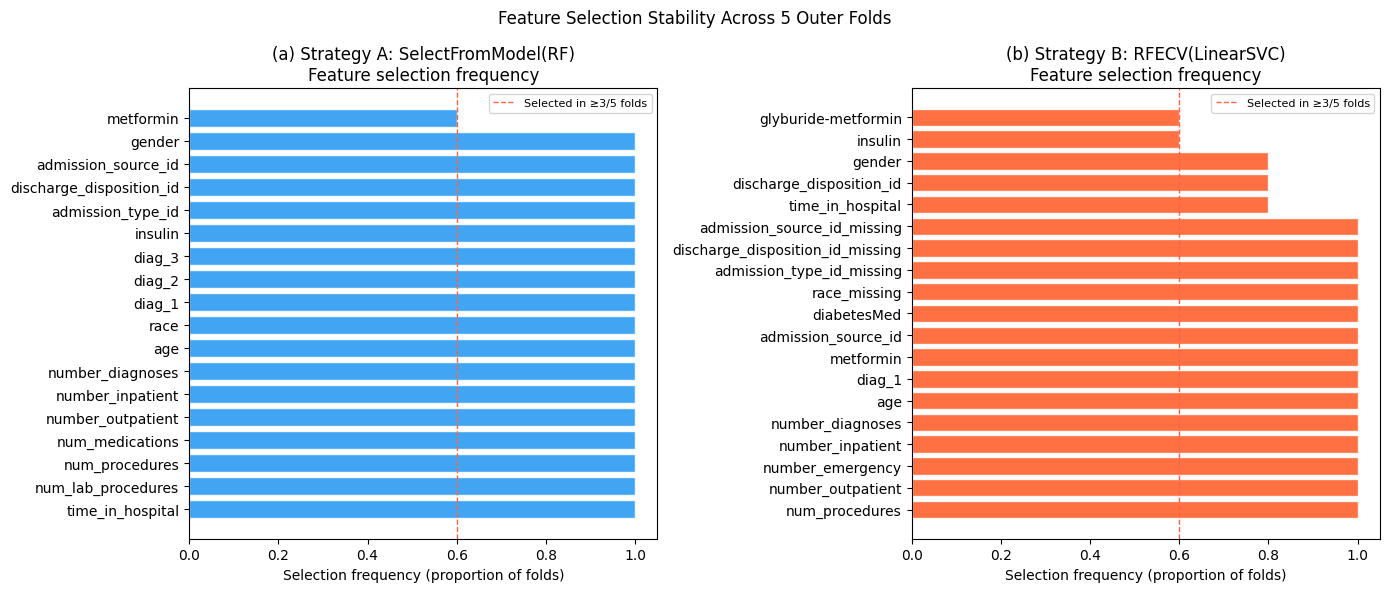

Fig 15 saved.

Strategy A: 18 features selected in ≥3/5 folds
Feature                                 Freq
---------------------------------------------
  time_in_hospital                         1.0
  num_lab_procedures                       1.0
  num_procedures                           1.0
  num_medications                          1.0
  number_outpatient                        1.0
  number_inpatient                         1.0
  number_diagnoses                         1.0
  age                                      1.0
  race                                     1.0
  diag_1                                   1.0
  diag_2                                   1.0
  diag_3                                   1.0
  insulin                                  1.0
  admission_type_id                        1.0
  discharge_disposition_id                 1.0
  admission_source_id                      1.0
  gender                                   1.0
  metformin                                0.6



In [ ]:
# stable_a already defined from Jaccard cell
# recompute stable_b in case not defined
stable_a = {all_feature_names[k]: v/5 for k, v in freq_a.items() if v >= 3}
stable_b = {all_feature_names[k]: v/5 for k, v in freq_b.items() if v >= 3}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Strategy A
sa_sorted = sorted(stable_a.items(), key=lambda x: x[1], reverse=True)
axes[0].barh([x[0] for x in sa_sorted], [x[1] for x in sa_sorted],
             color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(0.6, color='tomato', linestyle='--', linewidth=1,
                label='Selected in ≥3/5 folds')
axes[0].set_xlabel('Selection frequency (proportion of folds)')
axes[0].set_title('(a) Strategy A: SelectFromModel(RF)\nFeature selection frequency')
axes[0].legend(fontsize=8)

# Strategy B
sb_sorted = sorted(stable_b.items(), key=lambda x: x[1], reverse=True)
axes[1].barh([x[0] for x in sb_sorted], [x[1] for x in sb_sorted],
             color=COLORS[1], edgecolor='white', alpha=0.85)
axes[1].axvline(0.6, color='tomato', linestyle='--', linewidth=1,
                label='Selected in ≥3/5 folds')
axes[1].set_xlabel('Selection frequency (proportion of folds)')
axes[1].set_title('(b) Strategy B: RFECV(LinearSVC)\nFeature selection frequency')
axes[1].legend(fontsize=8)

plt.suptitle('Feature Selection Stability Across 5 Outer Folds',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGDIR + 'Fig15_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print('Fig 15 saved.')
print(f'\nStrategy A: {len(stable_a)} features selected in ≥3/5 folds')
print(f'{"Feature":<35} {"Freq":>8}')
print('-'*45)
for feat, freq in sa_sorted:
    print(f'  {feat:<35} {freq:>8.1f}')

print(f'\nStrategy B: {len(stable_b)} features selected in ≥3/5 folds')
print(f'{"Feature":<35} {"Freq":>8}')
print('-'*45)
for feat, freq in sb_sorted:
    print(f'  {feat:<35} {freq:>8.1f}')

print(f'\nModel-agnostic robust core (stable in both A and B, all 5 folds):')
for i in sorted(top_a & top_b):
    print(f'  {all_feature_names[i]}')